# ***Thesis Project by Group CLS***

***THESIS 1-3***

**Thesis Project**

**Group Members:**
*   Celles, Aaron Kent M.
*   Leviste, Lee Ryan A.
*   Santeco, Enrique S.

# ***Section 1. Introduction***

## **1.1 Problem Overview**

---



Large-scale global optimization (LSGO) presents a critical challenge in computational intelligence, where the "curse of dimensionality" leads to an explosive increase in local optima and a high risk of premature convergence. While foundational algorithms like Differential Evolution (DE) are robust, their dependence on crossover and random mutation may restrict guided exploration — reducing particle diversity over time and leading to premature convergence.

This notebook implements and evaluates the proposed **Diversity-Preserving Level-Based Learning Differential Evolution (DP-LLDE)** algorithm, tested against the **CEC 2017 Large-Scale Global Optimization Benchmark** across 29 benchmark functions (F1–F30, excluding deprecated F2) at **10 dimensions**.

## **1.2 Research Objectives**

---



1. Design and implement DP-LLDE, integrating sequential relative particle mutation and dynamic level-based learning into the Differential Evolution framework.
2. Evaluate DP-LLDE on the CEC 2017 benchmark suite (F1–F30) at 10 dimensions.
3. Examine convergence behavior, solution quality, and the effect of diversity-preserving strategies across unimodal, multimodal, hybrid, and composition functions.

## **1.3 Algorithm Overview - DP-LLDE**

---


DP-LLDE extends LBLDE (Qiao et al., 2022) with three core contributions:

1. **Sequential Level Assignment** — each individual is assigned a learning source level drawn randomly from {2, …, NL} on the first generation, decaying toward the elite level (level 1) in subsequent generations.
2. **Diversity-Aware Exemplar Selection** — if two exemplars e1, e2 fall below a diversity threshold, one is replaced with the most distant candidate in that level, preventing exemplar collapse.
3. **Normalized Mutation Pressure (Eq. 10):**

$$V_i = e_1 + F_i \times (e_2 - X_i) \times \frac{NL - k}{NL}$$

The factor $(NL-k)/NL$ decays to zero as $k \to NL$, naturally reducing mutation pressure as learning quality improves.

| Parameter | Value |
|-----------|-------|
| Population Size (NP) | 100 |
| Number of Levels (NL) | 4 |
| Initial μ_CR | 0.35 |
| Max FES | 10,000 × D |
| Dimensions (D) | 10 |
| Seed | 42 |

# ***Section 2. Benchmark Function Description***

## **2.1 Overview**

---


The **CEC 2017 Large-Scale Global Optimization Benchmark** (Awad et al., 2017) is a standardized suite of 30 test functions designed to evaluate optimization algorithms on complex, high-dimensional search spaces. The benchmark tests an algorithm's ability to avoid false local optima, convergence speed, and solution accuracy.

All functions are defined over the search space $[-100, 100]^D$ with their respective global optima offset by a function-specific bias value.

> **Library used:** `cec2017` by Duncan Tilley — provides the official shift vectors, rotation matrices, and shuffle permutations from the CEC 2017 specification.

## **2.2 Unimodal Function Overview**

---


Unimodal functions contain a **single global optimum and no local optima**. They are used to test the convergence speed and accuracy of an algorithm in a straightforward landscape.

| No. | Function Name | Global Optimum |
|-----|--------------|----------------|
| F1 | Shifted and Rotated Bent Cigar | 100 |
| F2 | Shifted and Rotated Sum of Different Power *(Deprecated)* | 200 |
| F3 | Shifted and Rotated Zakharov | 300 |

> **Note:** F2 is officially deprecated from the CEC 2017 benchmark but is included here for completeness as it remains implemented in the `cec2017` library.

## **2.3 Multimodal Function Overview**

---


Multimodal functions contain **multiple local optima**, making them significantly harder to solve. They are used to evaluate an algorithm's capacity to avoid premature convergence and escape false local optima.

| No. | Function Name | Global Optimum |
|-----|--------------|----------------|
| F4 | Shifted and Rotated Rosenbrock's | 400 |
| F5 | Shifted and Rotated Rastrigin's | 500 |
| F6 | Shifted and Rotated Expanded Schaffer's F6 | 600 |
| F7 | Shifted and Rotated Lunacek Bi-Rastrigin | 700 |
| F8 | Shifted and Rotated Non-Continuous Rastrigin's | 800 |
| F9 | Shifted and Rotated Levy | 900 |
| F10 | Shifted and Rotated Schwefel's | 1000 |

## **2.4 Hybrid Function Overview**

---


Hybrid functions divide the search space into several regions, each governed by a **different basic function**. They assess an algorithm's adaptability to heterogeneous landscapes and mixed search behaviors.

| No. | Component Functions | Global Optimum |
|-----|-------------------|----------------|
| F11 | Zakharov; Rosenbrock; Rastrigin | 1100 |
| F12 | Elliptic; Schwefel; Bent Cigar | 1200 |
| F13 | Bent Cigar; Rosenbrock; Bi-Rastrigin | 1300 |
| F14 | Elliptic; Ackley; Schaffer F7; Rastrigin | 1400 |
| F15 | Bent Cigar; HGBat; Rastrigin; Rosenbrock | 1500 |
| F16 | Schaffer F6; HGBat; Rosenbrock; Schwefel | 1600 |
| F17 | Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin | 1700 |
| F18 | Elliptic; Ackley; Rastrigin; HGBat; Discus | 1800 |
| F19 | Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer F6 | 1900 |
| F20 | HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer F7 | 2000 |

## **2.5 Composite Function Overview**

---


Composition functions **combine multiple shifted and rotated basic functions** into a single search space, creating highly complex and deceptive optimization landscapes. They are the most challenging category in the CEC 2017 suite and significantly test an algorithm's overall robustness and global search capability.

| No. | Component Functions | Global Optimum |
|-----|-------------------|----------------|
| F21 | Rosenbrock; Elliptic; Rastrigin | 2100 |
| F22 | Rastrigin; Griewank; Schwefel | 2200 |
| F23 | Rosenbrock; Ackley; Schwefel; Rastrigin | 2300 |
| F24 | Ackley; Elliptic; Griewank; Rastrigin | 2400 |
| F25 | Rastrigin; HappyCat; Ackley; Discus; Rosenbrock | 2500 |
| F26 | Schaffer F6; Schwefel; Griewank; Rosenbrock; Rastrigin | 2600 |
| F27 | HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer F6 | 2700 |
| F28 | Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer F6 | 2800 |
| F29 | F15; F16; F17 | 2900 |
| F30 | F15; F18; F19 | 3000 |

# ***Section 3. List of Required Libraries***

## **3.1 List of Libraries and Versions**

---



The following libraries and modules were used for optimization, benchmarking, and visualization in this project:

| Library / Module      | Purpose                                                                 | Version         |
|-----------------------|-------------------------------------------------------------------------|-----------------|
| `python`              | Core programming language                                               | 3.10+           |
| `numpy`               | Numerical computing and array operations                                | 2.0.2           |
| `matplotlib`          | Plotting and saving convergence graphs                                  | 3.10.0          |
| `cec2017`             | CEC 2017 benchmark functions (simple, hybrid, composition)              | Latest (pip)    |
| `cec2017.simple`      | Simple benchmark functions F1–F10                                       | —               |
| `cec2017.hybrid`      | Hybrid benchmark functions F11–F20                                      | —               |
| `cec2017.composition` | Composition benchmark functions F21–F30                                 | —               |
| `dpllde`              | DP-LLDE optimization algorithm (uploaded locally)                       | Custom          |
| `google.colab.files`  | File upload utility for loading `dpllde.py` into the Colab environment  | Built-in        |
| `sys`                 | Clears cached module before re-importing `dpllde.py`                    | Built-in        |

# ***Section 4. Environment Setup and Validation***





## **4.1 Installation**

Install `cec2017`

In [ ]:
!pip install cec2017 --quiet

ERROR: Could not find a version that satisfies the requirement cec2017 (from versions: none)
ERROR: No matching distribution found for cec2017


## **4.2 File Validation**

Import `simple.py`, `hybrid.py`, and `composition.py` python files for benchmark functions

In [3]:
from cec2017 import simple, hybrid, composition
print('cec2017 loaded!')

cec2017 loaded!


Import `sys` control over warning messages for verification that `dpllde.py` exists

In [1]:
from google.colab import files
import sys

uploaded = files.upload()

if 'lblde_mutation_rule.py' in uploaded:
    if 'lblde_mutation_rule' in sys.modules:
        del sys.modules['lblde']
    import lblde_mutation_rule
    from lblde_mutation_rule import LBLDE_MutationRule
    print('lblde_mutation_rule.py uploaded and imported successfully!')
else:
    print('ERROR: Please upload a file named lblde.py')

Saving lblde_mutation_rule.py to lblde_mutation_rule.py
lblde_mutation_rule.py uploaded and imported successfully!


# ***Section 5. Configuration and Helper Functions***

---



## **5.1 Library Imports**

Import libraries `numpy`, `matplotlib`, and `cec2017` for numerical computation, visualization, and CEC 2017 benchmark functions.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from cec2017 import simple, hybrid, composition

## **5.2 Global Parameters**

Define global parameters

In [5]:
D = 10 # Change this when testing different dimensions

In [6]:
bounds = np.array([[-100.0, 100.0]] * D)
MAX_FES = 10000 * D
NP, NL, MU_CR = 100, 4, 0.35
SEED = 42

Store all results for summary table under `all_results` dict

In [7]:
all_results = {}

## **5.3 Function Definitions**

Define `make_wrapper` to adapt CEC 2017 functions to accept a 1D input array from DP-LLDE, returning a large penalty value if the output is invalid (nan/inf).


In [8]:
def make_wrapper(fn):
    """Wrap a cec2017 function (expects (1,D) input) to accept (D,) input."""
    def wrapper(x):
        val = fn(x.reshape(1, -1))
        if hasattr(val, '__len__'):
            val = float(val[0])
        else:
            val = float(val)
        return val if np.isfinite(val) else 1e18
    return wrapper

Define `run_and_plot` to execute a single DP-LLDE optimization run on a given benchmark function, print the results, store them for the summary table, and save the convergence graph.

In [10]:
def run_and_plot(fn_name, fn_eval, f_global, fn_label):
    """Run LBLDE_m on a function and plot convergence + diversity graphs."""
    print('=' * 80)
    print(f'LBLDE_m on CEC 2017 {fn_name} — Single Run')
    print('=' * 80)
    print(f'Function       : {fn_label} ({D}D)')
    print(f'Bounds         : [-100, 100]')
    print(f'Global optimum : {f_global}')

    opt = LBLDE_MutationRule(
        objective_func=fn_eval,
        bounds=bounds,
        NP=NP, NL=NL, mu_CR_ini=MU_CR,
        max_fes=MAX_FES,
        seed=SEED
    )
    # ← Unpack 4 values now
    best_sol, best_fit, history, diversity_history = opt.optimize(verbose=True)

    error = abs(best_fit - f_global)
    print(f'\n{"="*80}')
    print('Results:')
    print(f'  Best Fitness           : {best_fit:.6e}')
    print(f'  Global Optimum         : {f_global:.6e}')
    print(f'  Error (|best-optimum|) : {error:.6e}')
    print(f'  Best Solution (5 dim)  : {best_sol[:5]}')
    print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
    print(f'{"="*80}')

    # Store for summary
    all_results[fn_name] = {
        'label': fn_label,
        'best_fit': best_fit,
        'f_global': f_global,
        'error': error
    }

    fes_axis = np.linspace(0, MAX_FES, len(history))
    gen_axis = np.arange(len(diversity_history))  # Generations (0, 1, 2, ...)

    # ── Two-panel figure ──────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    # Convergence curve (top) — FEs on x-axis
    ax1.plot(fes_axis, history, color='steelblue', linewidth=1.5)
    ax1.set_ylabel('Best Fitness', fontsize=12)
    ax1.set_xlabel('Function Evaluations (FEs)', fontsize=12)
    ax1.set_title(
        f'LBLDE_m — CEC 2017 {fn_name}: {fn_label} ({D}D)',
        fontsize=12
    )
    ax1.grid(True, which='both', linestyle='--', alpha=0.6)

    # Diversity curve (bottom) — Generations on x-axis
    ax2.plot(gen_axis, diversity_history, color='darkorange', linewidth=1.5)
    ax2.set_xlabel('Generation', fontsize=12)
    ax2.set_ylabel('Population Diversity\n(Mean Std Dev)', fontsize=12)
    ax2.set_title(f'Diversity Across Generations — {fn_name}', fontsize=12)
    ax2.grid(True, which='both', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fname = f'convergence_{fn_name}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Graph saved as {fname}\n')

# ***Section 6. CEC2017 Benchmark Functions***

---



## **6.1 Unimodal Functions (F1-F3)**

LBLDE_m on CEC 2017 F1 — Single Run
Function       : Shifted and Rotated Bent Cigar (10D)
Bounds         : [-100, 100]
Global optimum : 100.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.871674e+11  |  Diversity = 5.7928e+01
Generation   10: Best = 1.243388e+10  FES =   1100  Diversity = 1.4148e+01
Generation   20: Best = 1.569090e+09  FES =   2100  Diversity = 3.5379e+00
Generation   30: Best = 2.807006e+08  FES =   3100  Diversity = 1.0957e+00
Generation   40: Best = 7.892445e+07  FES =   4100  Diversity = 8.1056e-01
Generation   50: Best = 5.618036e+07  FES =   5100  Diversity = 7.9271e-01
Generation   60: Best = 4.610153e+07  FES =   6100  Diversity = 1.0687e+00
Generation   70: Best = 4.187752e+07  FES =   7100  Diversity = 2.0873e+00
Generation   80: Best = 3.719753e+07  FES =   8100  Diversity = 3.7621e+00
Generation   90: Best = 3.048252e+07  FES =   9100  Diversity = 4.5518e+00
Generation  100: Best = 2.498019e+07  FES =  10100

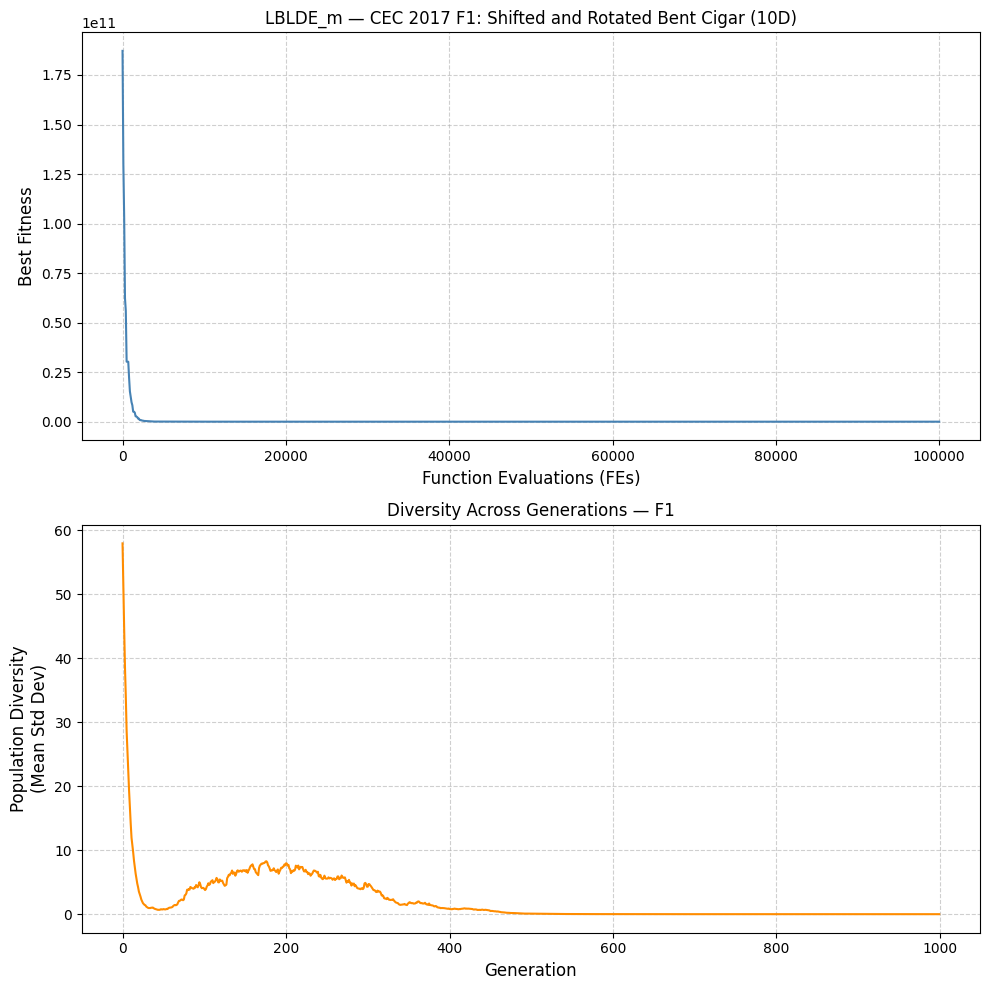

Graph saved as convergence_F1.png



In [11]:
# ============================================================
# F1 — Shifted and Rotated Bent Cigar
# ============================================================
run_and_plot('F1', make_wrapper(simple.f1), 100.0, 'Shifted and Rotated Bent Cigar')

LBLDE_m on CEC 2017 F2 — Single Run
Function       : Shifted and Rotated Sum of Different Power (Deprecated) (10D)
Bounds         : [-100, 100]
Global optimum : 200.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.603565e+14  |  Diversity = 5.7928e+01
Generation   10: Best = 3.676803e+07  FES =   1100  Diversity = 2.4539e+01
Generation   20: Best = 5.171569e+05  FES =   2100  Diversity = 1.0504e+01
Generation   30: Best = 1.737358e+04  FES =   3100  Diversity = 6.2989e+00
Generation   40: Best = 3.652031e+03  FES =   4100  Diversity = 2.5152e+00
Generation   50: Best = 2.668524e+03  FES =   5100  Diversity = 1.2508e+00
Generation   60: Best = 2.488883e+03  FES =   6100  Diversity = 1.0452e+00
Generation   70: Best = 2.405264e+03  FES =   7100  Diversity = 6.9493e-01
Generation   80: Best = 2.383745e+03  FES =   8100  Diversity = 3.6916e-01
Generation   90: Best = 2.376560e+03  FES =   9100  Diversity = 2.2835e-01
Generation  100: Best = 2

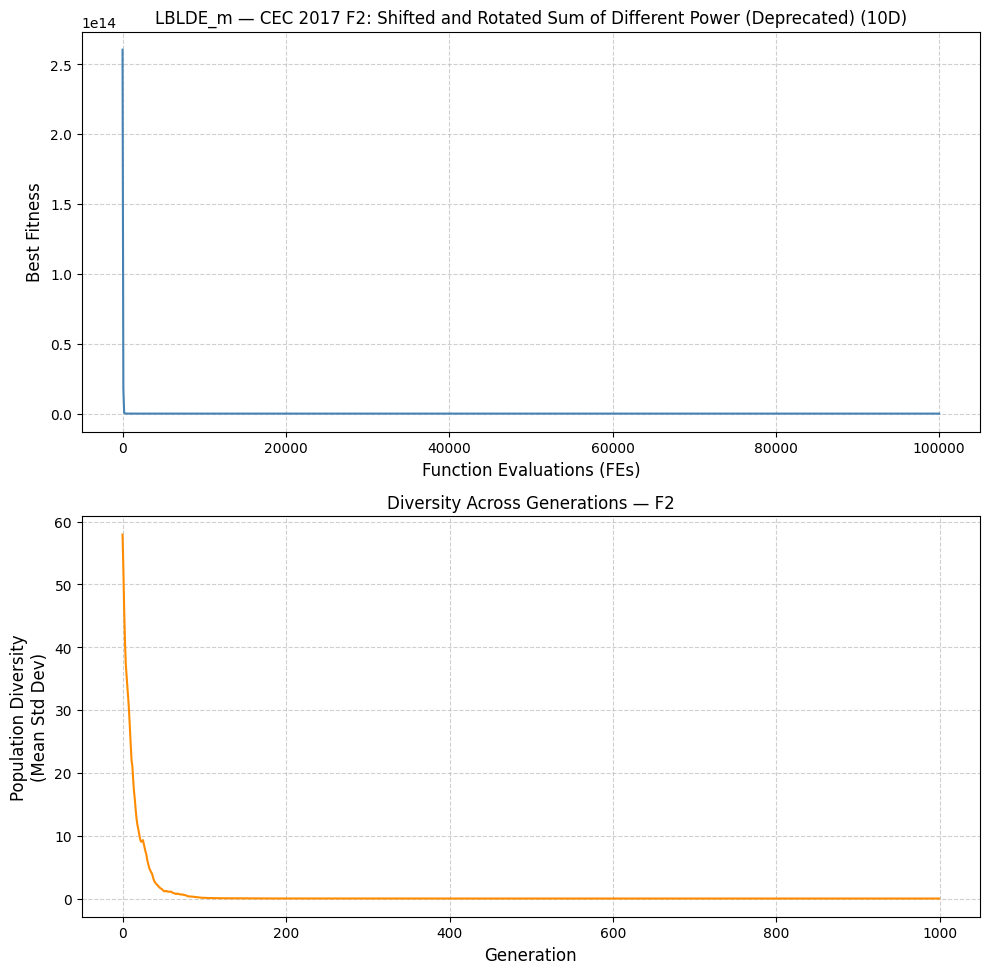

Graph saved as convergence_F2.png



In [12]:
# ============================================================
# F2 — Shifted and Rotated Sum of Different Power
# ============================================================
run_and_plot('F2', make_wrapper(simple.f2), 200.0, 'Shifted and Rotated Sum of Different Power (Deprecated)')

LBLDE_m on CEC 2017 F3 — Single Run
Function       : Shifted and Rotated Zakharov (10D)
Bounds         : [-100, 100]
Global optimum : 300.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.625937e+04  |  Diversity = 5.7928e+01
Generation   10: Best = 1.044934e+04  FES =   1100  Diversity = 4.0412e+01
Generation   20: Best = 5.114906e+03  FES =   2100  Diversity = 2.4307e+01
Generation   30: Best = 2.407273e+03  FES =   3100  Diversity = 1.3316e+01
Generation   40: Best = 1.207255e+03  FES =   4100  Diversity = 7.3778e+00
Generation   50: Best = 8.612900e+02  FES =   5100  Diversity = 4.1243e+00
Generation   60: Best = 6.232040e+02  FES =   6100  Diversity = 2.3730e+00
Generation   70: Best = 5.616293e+02  FES =   7100  Diversity = 1.4500e+00
Generation   80: Best = 5.085892e+02  FES =   8100  Diversity = 1.0955e+00
Generation   90: Best = 4.646771e+02  FES =   9100  Diversity = 6.2988e-01
Generation  100: Best = 4.418431e+02  FES =  10100  

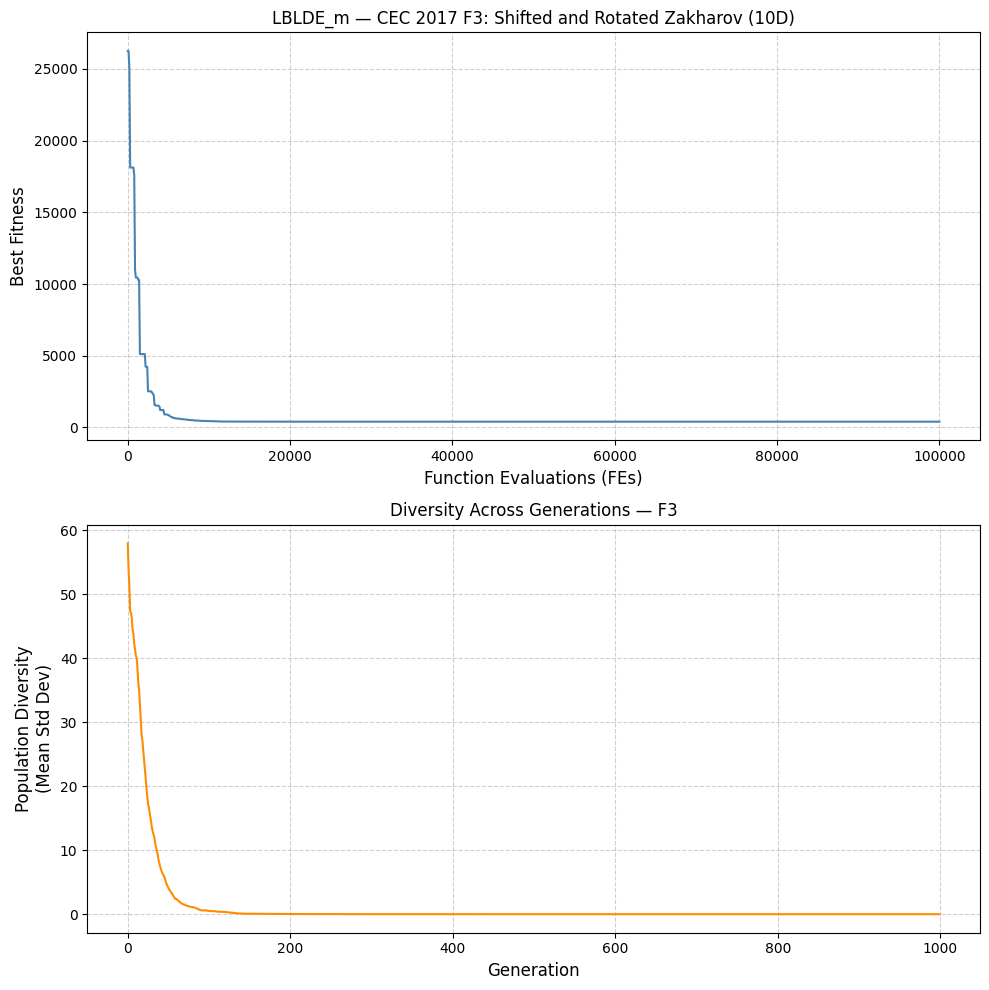

Graph saved as convergence_F3.png



In [13]:
# ============================================================
# F3 — Shifted and Rotated Zakharov
# ============================================================
run_and_plot('F3', make_wrapper(simple.f3), 300.0, 'Shifted and Rotated Zakharov')

## **6.2 Multimodal Functions (F4-F10)**

LBLDE_m on CEC 2017 F4 — Single Run
Function       : Shifted and Rotated Rosenbrock's (10D)
Bounds         : [-100, 100]
Global optimum : 400.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.004346e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 5.038440e+02  FES =   1100  Diversity = 1.7564e+01
Generation   20: Best = 4.403234e+02  FES =   2100  Diversity = 4.7838e+00
Generation   30: Best = 4.246175e+02  FES =   3100  Diversity = 1.7035e+00
Generation   40: Best = 4.188484e+02  FES =   4100  Diversity = 1.5970e+00
Generation   50: Best = 4.143434e+02  FES =   5100  Diversity = 3.4280e+00
Generation   60: Best = 4.094306e+02  FES =   6100  Diversity = 5.3827e+00
Generation   70: Best = 4.061091e+02  FES =   7100  Diversity = 1.1826e+00
Generation   80: Best = 4.050724e+02  FES =   8100  Diversity = 6.8501e-01
Generation   90: Best = 4.045000e+02  FES =   9100  Diversity = 4.2875e-01
Generation  100: Best = 4.041618e+02  FES =  101

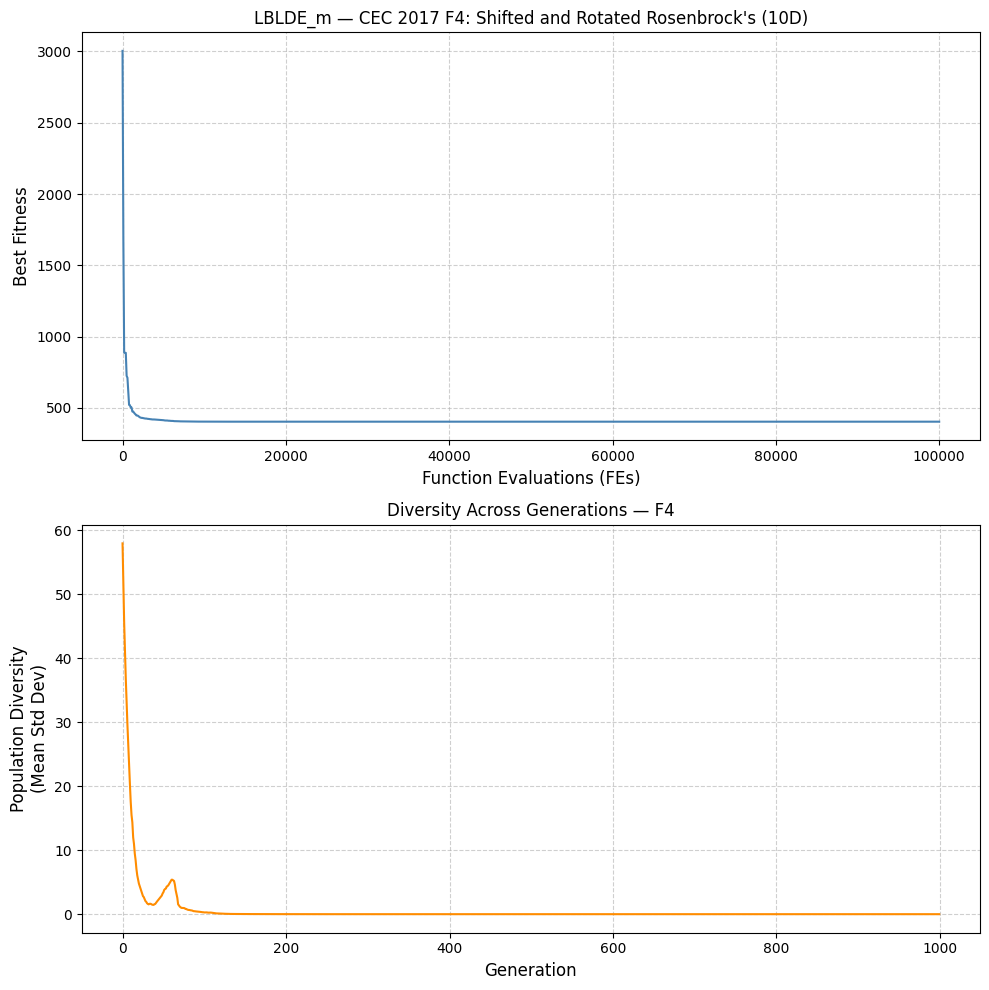

Graph saved as convergence_F4.png



In [14]:
# ============================================================
# F4 — Shifted and Rotated Rosenbrock
# ============================================================
run_and_plot('F4', make_wrapper(simple.f4), 400.0, "Shifted and Rotated Rosenbrock's")

LBLDE_m on CEC 2017 F5 — Single Run
Function       : Shifted and Rotated Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 500.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 6.377184e+02  |  Diversity = 5.7928e+01
Generation   10: Best = 5.673787e+02  FES =   1100  Diversity = 2.3493e+01
Generation   20: Best = 5.503506e+02  FES =   2100  Diversity = 1.9775e+01
Generation   30: Best = 5.374556e+02  FES =   3100  Diversity = 1.7487e+01
Generation   40: Best = 5.275415e+02  FES =   4100  Diversity = 1.6740e+01
Generation   50: Best = 5.258471e+02  FES =   5100  Diversity = 1.5586e+01
Generation   60: Best = 5.258471e+02  FES =   6100  Diversity = 1.5279e+01
Generation   70: Best = 5.258471e+02  FES =   7100  Diversity = 1.4809e+01
Generation   80: Best = 5.258423e+02  FES =   8100  Diversity = 1.4491e+01
Generation   90: Best = 5.220593e+02  FES =   9100  Diversity = 1.4327e+01
Generation  100: Best = 5.215429e+02  FES =  1010

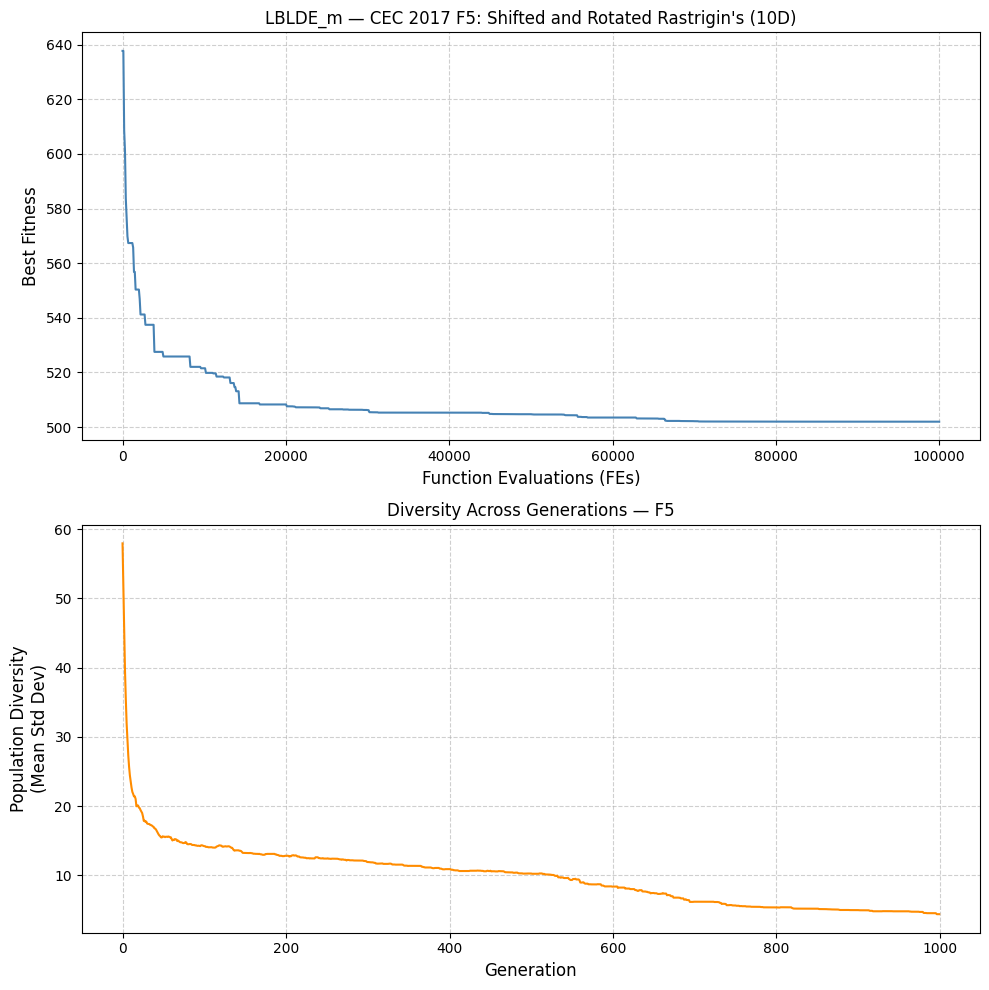

Graph saved as convergence_F5.png



In [15]:
# ============================================================
# F5 — Shifted and Rotated Rastrigin
# ============================================================
run_and_plot('F5', make_wrapper(simple.f5), 500.0, "Shifted and Rotated Rastrigin's")

LBLDE_m on CEC 2017 F6 — Single Run
Function       : Shifted and Rotated Schaffer's F7 (10D)
Bounds         : [-100, 100]
Global optimum : 600.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 7.140452e+02  |  Diversity = 5.7928e+01
Generation   10: Best = 6.292080e+02  FES =   1100  Diversity = 2.1218e+01
Generation   20: Best = 6.159205e+02  FES =   2100  Diversity = 8.6178e+00
Generation   30: Best = 6.068768e+02  FES =   3100  Diversity = 5.4726e+00
Generation   40: Best = 6.029094e+02  FES =   4100  Diversity = 1.9900e+00
Generation   50: Best = 6.021060e+02  FES =   5100  Diversity = 1.4481e+00
Generation   60: Best = 6.016875e+02  FES =   6100  Diversity = 1.7013e+00
Generation   70: Best = 6.014871e+02  FES =   7100  Diversity = 1.9534e+00
Generation   80: Best = 6.010905e+02  FES =   8100  Diversity = 2.1915e+00
Generation   90: Best = 6.006035e+02  FES =   9100  Diversity = 2.0857e+00
Generation  100: Best = 6.004683e+02  FES =  10

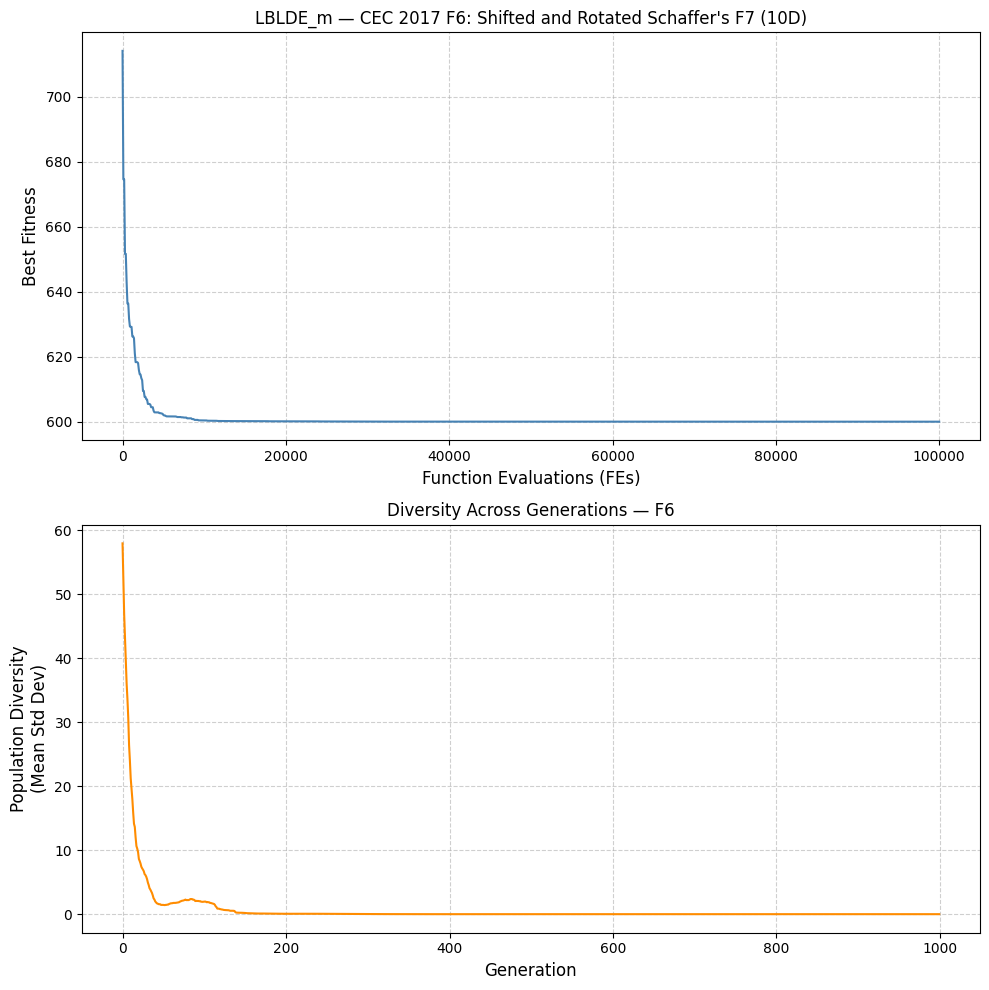

Graph saved as convergence_F6.png



In [16]:
# ============================================================
# F6 — Shifted and Rotated Schaffer's F7
# ============================================================
run_and_plot('F6', make_wrapper(simple.f6), 600.0, "Shifted and Rotated Schaffer's F7")

LBLDE_m on CEC 2017 F7 — Single Run
Function       : Shifted and Rotated Lunacek Bi-Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 700.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.202264e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 7.892390e+02  FES =   1100  Diversity = 1.2520e+01
Generation   20: Best = 7.471439e+02  FES =   2100  Diversity = 8.4922e+00
Generation   30: Best = 7.436953e+02  FES =   3100  Diversity = 7.0454e+00
Generation   40: Best = 7.411768e+02  FES =   4100  Diversity = 6.7862e+00
Generation   50: Best = 7.396145e+02  FES =   5100  Diversity = 6.2869e+00
Generation   60: Best = 7.373214e+02  FES =   6100  Diversity = 6.0975e+00
Generation   70: Best = 7.373214e+02  FES =   7100  Diversity = 6.1603e+00
Generation   80: Best = 7.351530e+02  FES =   8100  Diversity = 5.7986e+00
Generation   90: Best = 7.351530e+02  FES =   9100  Diversity = 5.7278e+00
Generation  100: Best = 7.351530e+02  

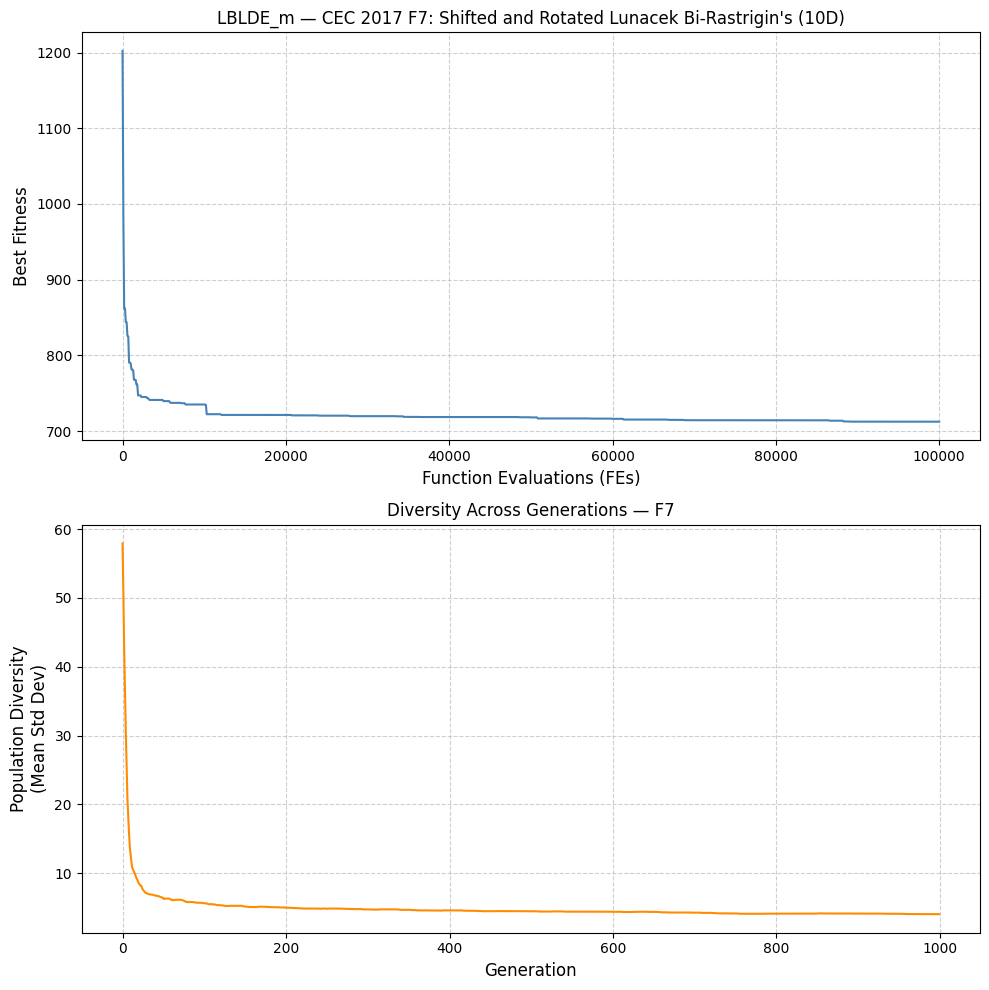

Graph saved as convergence_F7.png



In [17]:
# ============================================================
# F7 — Shifted and Rotated Lunacek Bi-Rastrigin
# ============================================================
run_and_plot('F7', make_wrapper(simple.f7), 700.0, "Shifted and Rotated Lunacek Bi-Rastrigin's")

LBLDE_m on CEC 2017 F8 — Single Run
Function       : Shifted and Rotated Non-Continuous Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 800.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 9.505966e+02  |  Diversity = 5.7928e+01
Generation   10: Best = 8.604851e+02  FES =   1100  Diversity = 2.3781e+01
Generation   20: Best = 8.419766e+02  FES =   2100  Diversity = 1.8002e+01
Generation   30: Best = 8.298290e+02  FES =   3100  Diversity = 1.6080e+01
Generation   40: Best = 8.298290e+02  FES =   4100  Diversity = 1.5595e+01
Generation   50: Best = 8.239656e+02  FES =   5100  Diversity = 1.4662e+01
Generation   60: Best = 8.155328e+02  FES =   6100  Diversity = 1.4394e+01
Generation   70: Best = 8.145272e+02  FES =   7100  Diversity = 1.3987e+01
Generation   80: Best = 8.103535e+02  FES =   8100  Diversity = 1.3779e+01
Generation   90: Best = 8.101322e+02  FES =   9100  Diversity = 1.3545e+01
Generation  100: Best = 8.086399e+

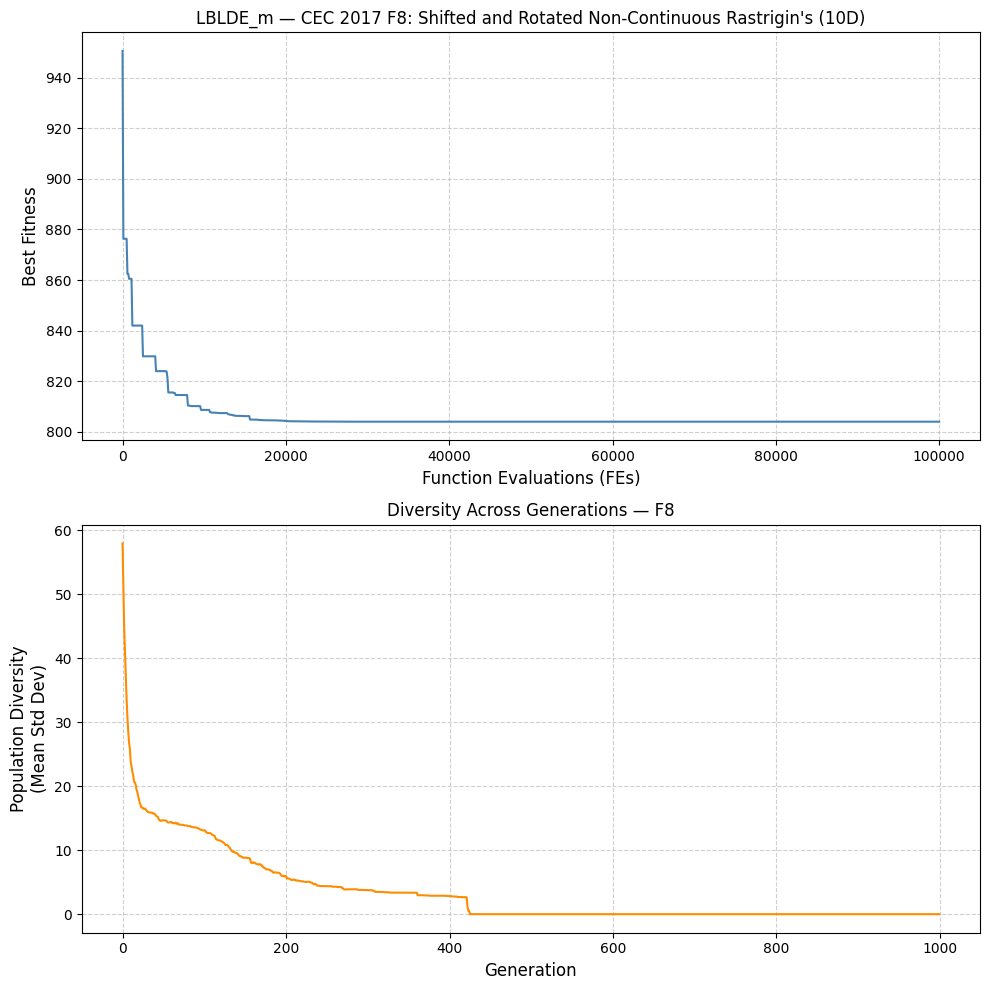

Graph saved as convergence_F8.png



In [18]:
# ============================================================
# F8 — Shifted and Rotated Non-Continuous Rastrigin
# ============================================================
run_and_plot('F8', make_wrapper(simple.f8), 800.0, "Shifted and Rotated Non-Continuous Rastrigin's")

LBLDE_m on CEC 2017 F9 — Single Run
Function       : Shifted and Rotated Levy (10D)
Bounds         : [-100, 100]
Global optimum : 900.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 6.112557e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 1.265937e+03  FES =   1100  Diversity = 2.1455e+01
Generation   20: Best = 9.823649e+02  FES =   2100  Diversity = 8.3759e+00
Generation   30: Best = 9.141061e+02  FES =   3100  Diversity = 3.3460e+00
Generation   40: Best = 9.027662e+02  FES =   4100  Diversity = 1.4020e+00
Generation   50: Best = 9.014648e+02  FES =   5100  Diversity = 8.7722e-01
Generation   60: Best = 9.006654e+02  FES =   6100  Diversity = 3.6434e-01
Generation   70: Best = 9.002985e+02  FES =   7100  Diversity = 2.5958e-01
Generation   80: Best = 9.002428e+02  FES =   8100  Diversity = 6.8930e-02
Generation   90: Best = 9.002190e+02  FES =   9100  Diversity = 4.9366e-02
Generation  100: Best = 9.001987e+02  FES =  10100  Dive

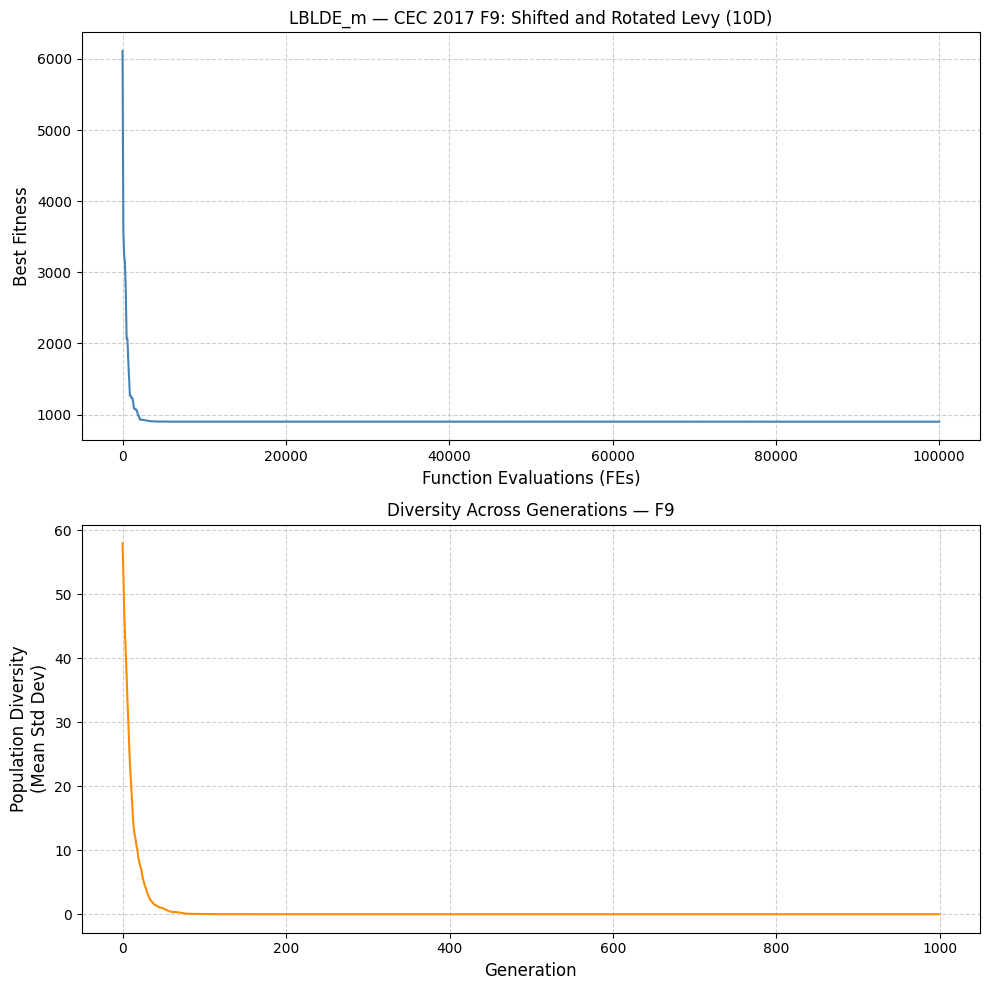

Graph saved as convergence_F9.png



In [19]:
# ============================================================
# F9 — Shifted and Rotated Levy
# ============================================================
run_and_plot('F9', make_wrapper(simple.f9), 900.0, 'Shifted and Rotated Levy')

LBLDE_m on CEC 2017 F10 — Single Run
Function       : Shifted and Rotated Schwefel's (10D)
Bounds         : [-100, 100]
Global optimum : 1000.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.749402e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.885491e+03  FES =   1100  Diversity = 4.8046e+01
Generation   20: Best = 2.783544e+03  FES =   2100  Diversity = 4.4235e+01
Generation   30: Best = 2.306192e+03  FES =   3100  Diversity = 4.3397e+01
Generation   40: Best = 2.306192e+03  FES =   4100  Diversity = 4.3142e+01
Generation   50: Best = 2.172570e+03  FES =   5100  Diversity = 4.2486e+01
Generation   60: Best = 2.172570e+03  FES =   6100  Diversity = 4.2366e+01
Generation   70: Best = 2.172570e+03  FES =   7100  Diversity = 4.1654e+01
Generation   80: Best = 1.884825e+03  FES =   8100  Diversity = 4.0635e+01
Generation   90: Best = 1.884825e+03  FES =   9100  Diversity = 3.8660e+01
Generation  100: Best = 1.769840e+03  FES =  101

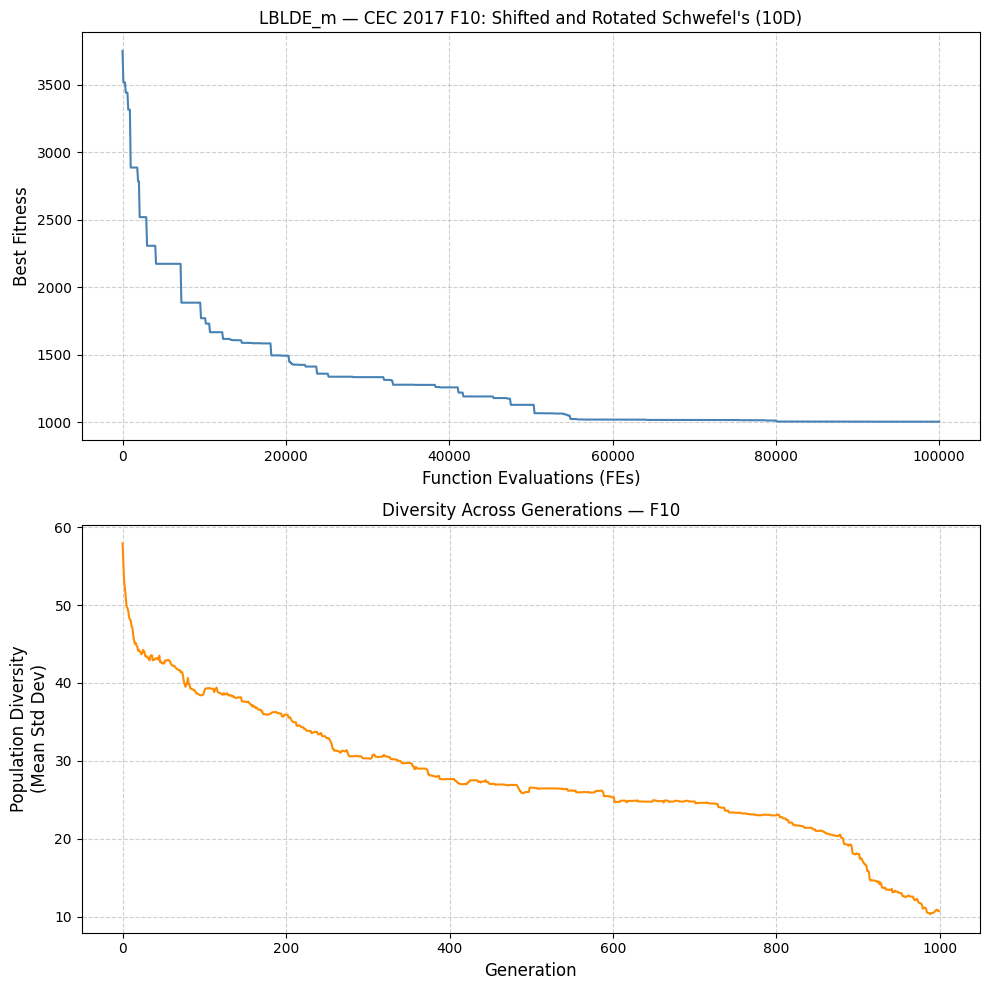

Graph saved as convergence_F10.png



In [20]:
# ============================================================
# F10 — Shifted and Rotated Schwefel
# ============================================================
run_and_plot('F10', make_wrapper(simple.f10), 1000.0, "Shifted and Rotated Schwefel's")

## **6.3 Hybrid Functions (F11-F20)**

LBLDE_m on CEC 2017 F11 — Single Run
Function       : Hybrid: Zakharov; Rosenbrock; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1100.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.292232e+04  |  Diversity = 5.7928e+01
Generation   10: Best = 1.278040e+03  FES =   1100  Diversity = 2.5734e+01
Generation   20: Best = 1.152736e+03  FES =   2100  Diversity = 9.2399e+00
Generation   30: Best = 1.128431e+03  FES =   3100  Diversity = 5.5725e+00
Generation   40: Best = 1.121178e+03  FES =   4100  Diversity = 4.2241e+00
Generation   50: Best = 1.118226e+03  FES =   5100  Diversity = 3.8309e+00
Generation   60: Best = 1.115263e+03  FES =   6100  Diversity = 3.2852e+00
Generation   70: Best = 1.114778e+03  FES =   7100  Diversity = 3.0257e+00
Generation   80: Best = 1.112912e+03  FES =   8100  Diversity = 3.0287e+00
Generation   90: Best = 1.111805e+03  FES =   9100  Diversity = 2.9600e+00
Generation  100: Best = 1.111367e+03  F

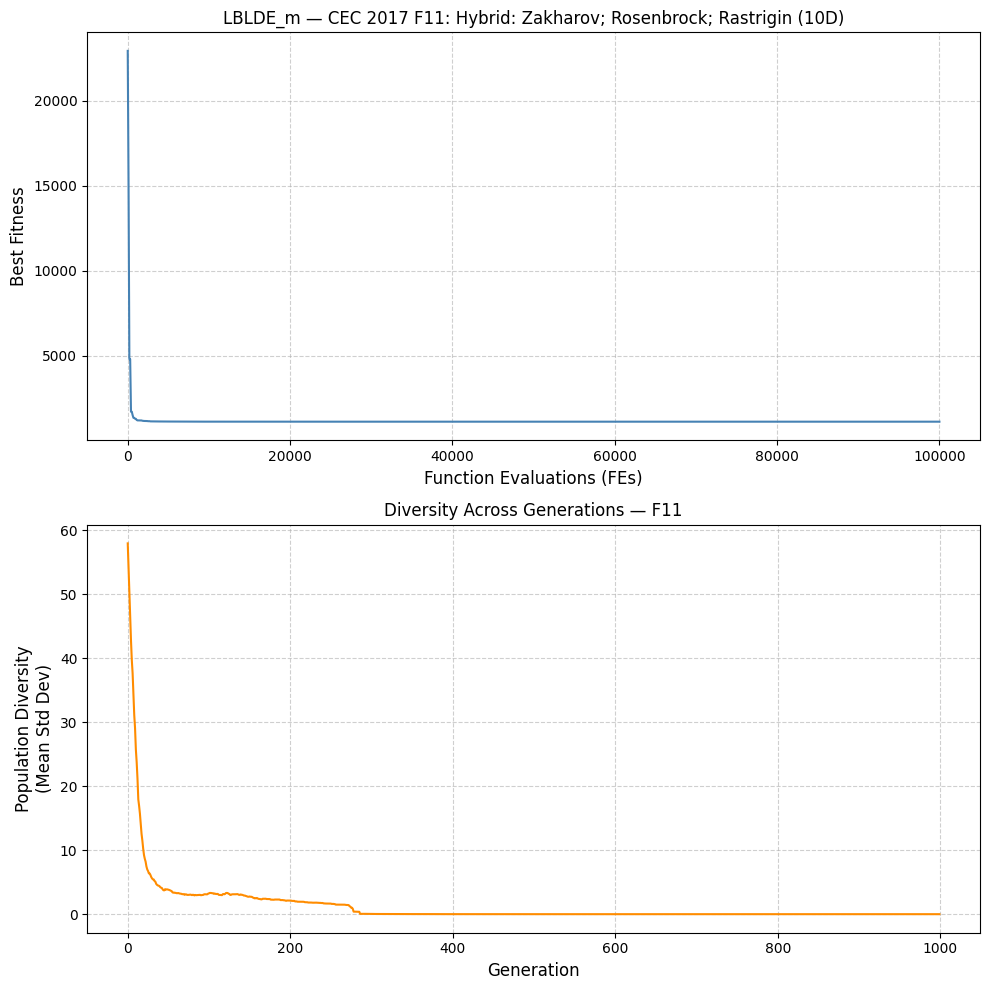

Graph saved as convergence_F11.png



In [21]:
# ============================================================
# F11 — Hybrid Function 1 (Zakharov; Rosenbrock; Rastrigin)
# ============================================================
run_and_plot('F11', make_wrapper(hybrid.f11), 1100.0, 'Hybrid: Zakharov; Rosenbrock; Rastrigin')

LBLDE_m on CEC 2017 F12 — Single Run
Function       : Hybrid: Elliptic; Schwefel; Bent Cigar (10D)
Bounds         : [-100, 100]
Global optimum : 1200.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 7.052719e+09  |  Diversity = 5.7928e+01
Generation   10: Best = 6.041338e+07  FES =   1100  Diversity = 2.1874e+01
Generation   20: Best = 4.913739e+06  FES =   2100  Diversity = 1.1628e+01
Generation   30: Best = 7.803958e+05  FES =   3100  Diversity = 1.0538e+01
Generation   40: Best = 5.218510e+04  FES =   4100  Diversity = 9.0477e+00
Generation   50: Best = 1.195518e+04  FES =   5100  Diversity = 9.5197e+00
Generation   60: Best = 1.195518e+04  FES =   6100  Diversity = 7.0929e+00
Generation   70: Best = 6.885572e+03  FES =   7100  Diversity = 7.2510e+00
Generation   80: Best = 4.315890e+03  FES =   8100  Diversity = 8.2961e+00
Generation   90: Best = 3.643766e+03  FES =   9100  Diversity = 8.6074e+00
Generation  100: Best = 2.513406e+03  FE

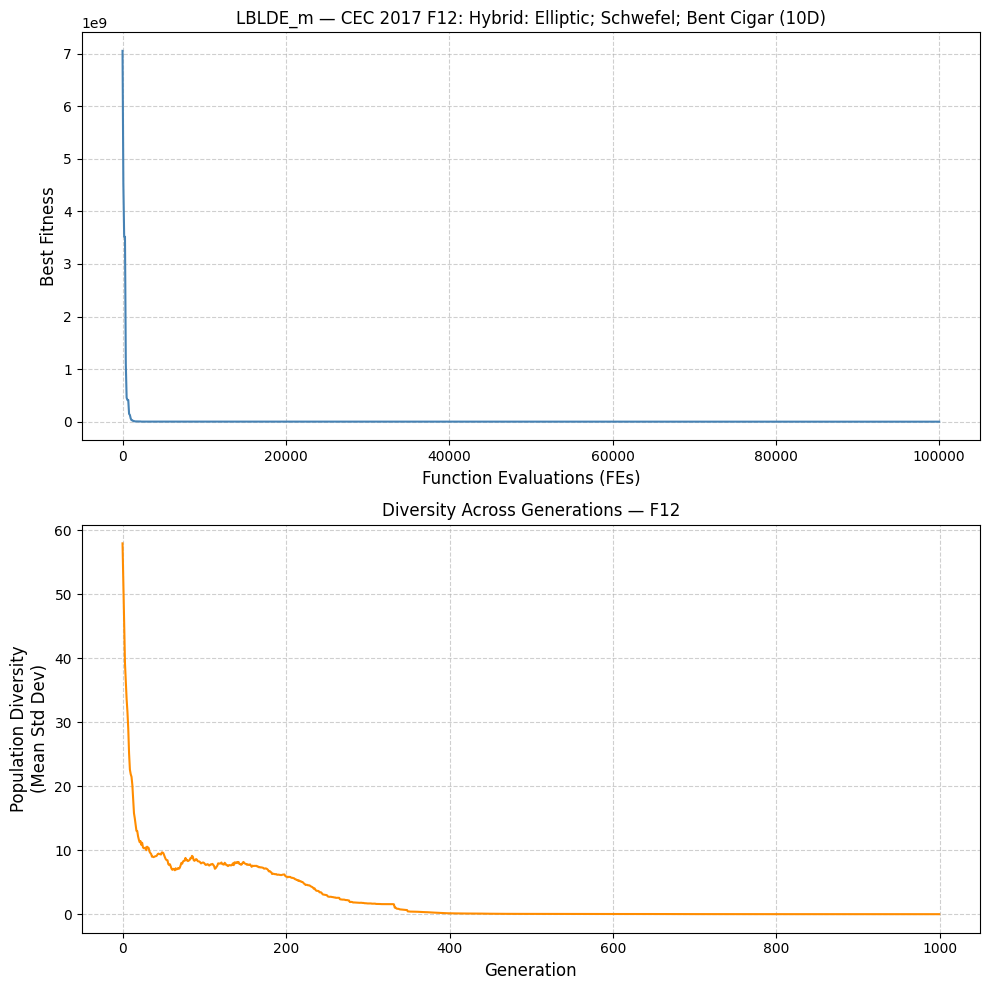

Graph saved as convergence_F12.png



In [22]:
# ============================================================
# F12 — Hybrid Function 2 (Elliptic; Schwefel; Bent Cigar)
# ============================================================
run_and_plot('F12', make_wrapper(hybrid.f12), 1200.0, 'Hybrid: Elliptic; Schwefel; Bent Cigar')

LBLDE_m on CEC 2017 F13 — Single Run
Function       : Hybrid: Bent Cigar; Rosenbrock; Bi-Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1300.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.212051e+09  |  Diversity = 5.7928e+01
Generation   10: Best = 3.801345e+05  FES =   1100  Diversity = 2.7386e+01
Generation   20: Best = 1.609519e+04  FES =   2100  Diversity = 2.5851e+01
Generation   30: Best = 3.131154e+03  FES =   3100  Diversity = 2.5452e+01
Generation   40: Best = 1.923229e+03  FES =   4100  Diversity = 1.7464e+01
Generation   50: Best = 1.617218e+03  FES =   5100  Diversity = 1.4334e+01
Generation   60: Best = 1.505835e+03  FES =   6100  Diversity = 1.0800e+01
Generation   70: Best = 1.334744e+03  FES =   7100  Diversity = 8.7064e+00
Generation   80: Best = 1.334744e+03  FES =   8100  Diversity = 7.5680e+00
Generation   90: Best = 1.334744e+03  FES =   9100  Diversity = 7.1764e+00
Generation  100: Best = 1.320385e+

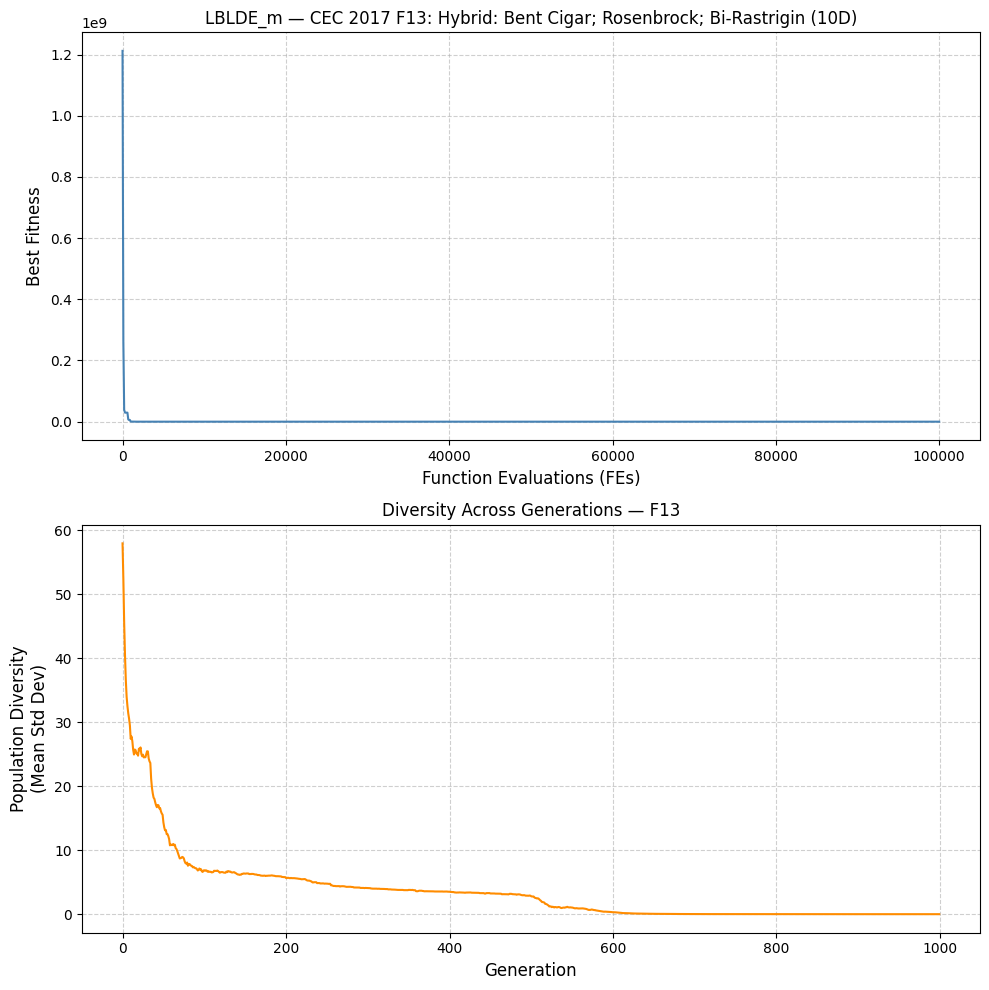

Graph saved as convergence_F13.png



In [23]:
# ============================================================
# F13 — Hybrid Function 3 (Bent Cigar; Rosenbrock; Bi-Rastrigin)
# ============================================================
run_and_plot('F13', make_wrapper(hybrid.f13), 1300.0, 'Hybrid: Bent Cigar; Rosenbrock; Bi-Rastrigin')

LBLDE_m on CEC 2017 F14 — Single Run
Function       : Hybrid: Elliptic; Ackley; Schaffer; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1400.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.917787e+04  |  Diversity = 5.7928e+01
Generation   10: Best = 4.604853e+03  FES =   1100  Diversity = 3.2568e+01
Generation   20: Best = 1.991489e+03  FES =   2100  Diversity = 2.5161e+01
Generation   30: Best = 1.666800e+03  FES =   3100  Diversity = 2.1105e+01
Generation   40: Best = 1.556155e+03  FES =   4100  Diversity = 1.9741e+01
Generation   50: Best = 1.479517e+03  FES =   5100  Diversity = 1.8048e+01
Generation   60: Best = 1.453979e+03  FES =   6100  Diversity = 1.2972e+01
Generation   70: Best = 1.439425e+03  FES =   7100  Diversity = 9.6709e+00
Generation   80: Best = 1.430381e+03  FES =   8100  Diversity = 8.0469e+00
Generation   90: Best = 1.428208e+03  FES =   9100  Diversity = 6.1708e+00
Generation  100: Best = 1.426450e

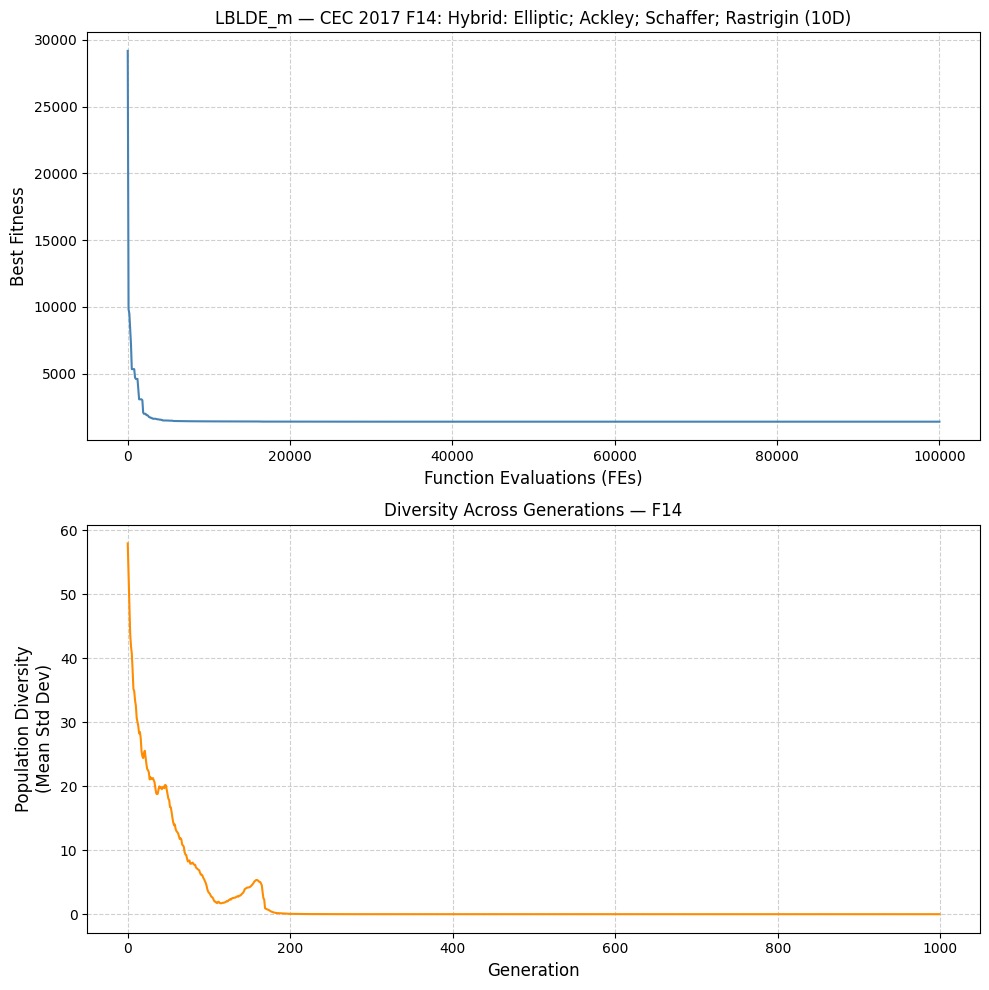

Graph saved as convergence_F14.png



In [24]:
# ============================================================
# F14 — Hybrid Function 4 (Elliptic; Ackley; Schaffer; Rastrigin)
# ============================================================
run_and_plot('F14', make_wrapper(hybrid.f14), 1400.0, 'Hybrid: Elliptic; Ackley; Schaffer; Rastrigin')

LBLDE_m on CEC 2017 F15 — Single Run
Function       : Hybrid: Bent Cigar; HGBat; Rastrigin; Rosenbrock (10D)
Bounds         : [-100, 100]
Global optimum : 1500.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.114909e+07  |  Diversity = 5.7928e+01
Generation   10: Best = 6.168391e+03  FES =   1100  Diversity = 3.3983e+01
Generation   20: Best = 2.219679e+03  FES =   2100  Diversity = 2.5255e+01
Generation   30: Best = 1.580374e+03  FES =   3100  Diversity = 1.4541e+01
Generation   40: Best = 1.540833e+03  FES =   4100  Diversity = 7.1437e+00
Generation   50: Best = 1.533040e+03  FES =   5100  Diversity = 5.5449e+00
Generation   60: Best = 1.524574e+03  FES =   6100  Diversity = 4.8127e+00
Generation   70: Best = 1.520500e+03  FES =   7100  Diversity = 4.3565e+00
Generation   80: Best = 1.517386e+03  FES =   8100  Diversity = 4.3244e+00
Generation   90: Best = 1.515501e+03  FES =   9100  Diversity = 3.7616e+00
Generation  100: Best = 1.5133

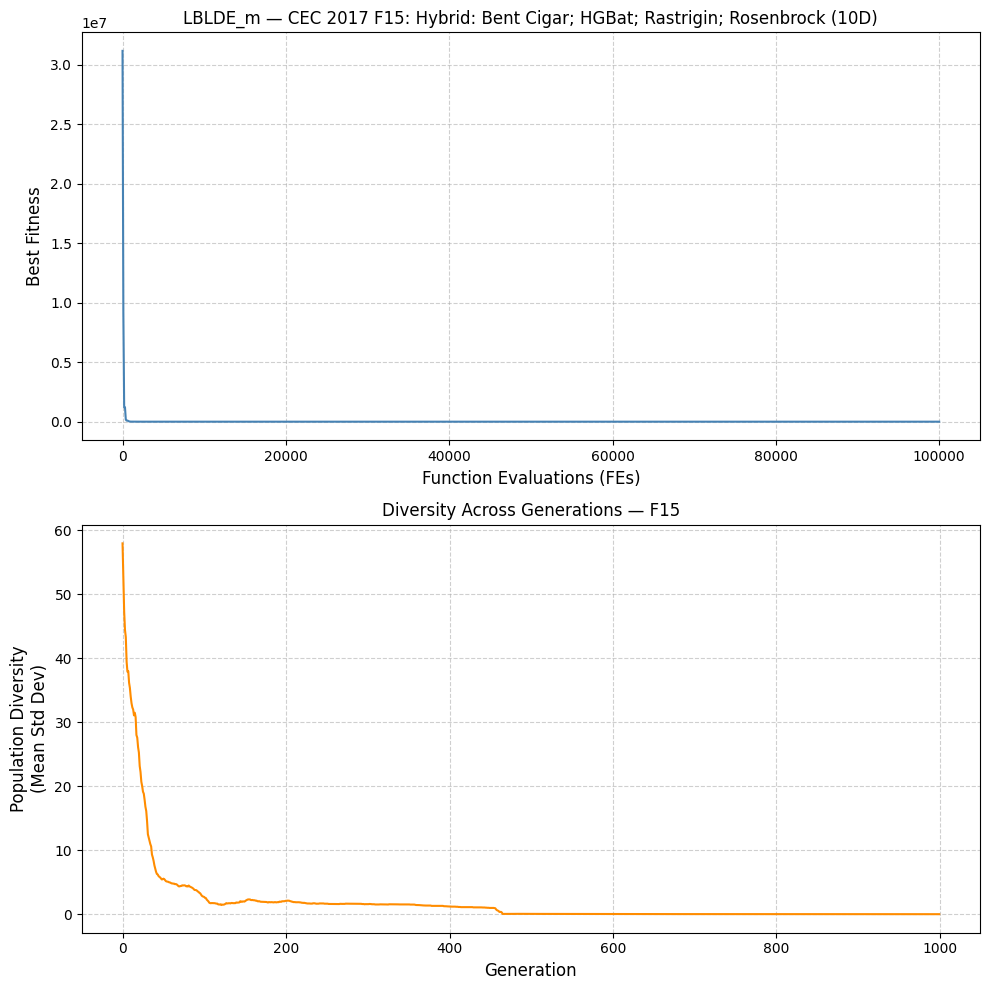

Graph saved as convergence_F15.png



In [25]:
# ============================================================
# F15 — Hybrid Function 5 (Bent Cigar; HGBat; Rastrigin; Rosenbrock)
# ============================================================
run_and_plot('F15', make_wrapper(hybrid.f15), 1500.0, 'Hybrid: Bent Cigar; HGBat; Rastrigin; Rosenbrock')

LBLDE_m on CEC 2017 F16 — Single Run
Function       : Hybrid: Schaffer; HGBat; Rosenbrock; Schwefel (10D)
Bounds         : [-100, 100]
Global optimum : 1600.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.512498e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.113147e+03  FES =   1100  Diversity = 3.3318e+01
Generation   20: Best = 1.860467e+03  FES =   2100  Diversity = 2.9068e+01
Generation   30: Best = 1.734070e+03  FES =   3100  Diversity = 2.6609e+01
Generation   40: Best = 1.668069e+03  FES =   4100  Diversity = 2.3746e+01
Generation   50: Best = 1.607526e+03  FES =   5100  Diversity = 2.1241e+01
Generation   60: Best = 1.605668e+03  FES =   6100  Diversity = 1.8504e+01
Generation   70: Best = 1.605043e+03  FES =   7100  Diversity = 1.5549e+01
Generation   80: Best = 1.603952e+03  FES =   8100  Diversity = 1.2768e+01
Generation   90: Best = 1.603543e+03  FES =   9100  Diversity = 8.0003e+00
Generation  100: Best = 1.603096e

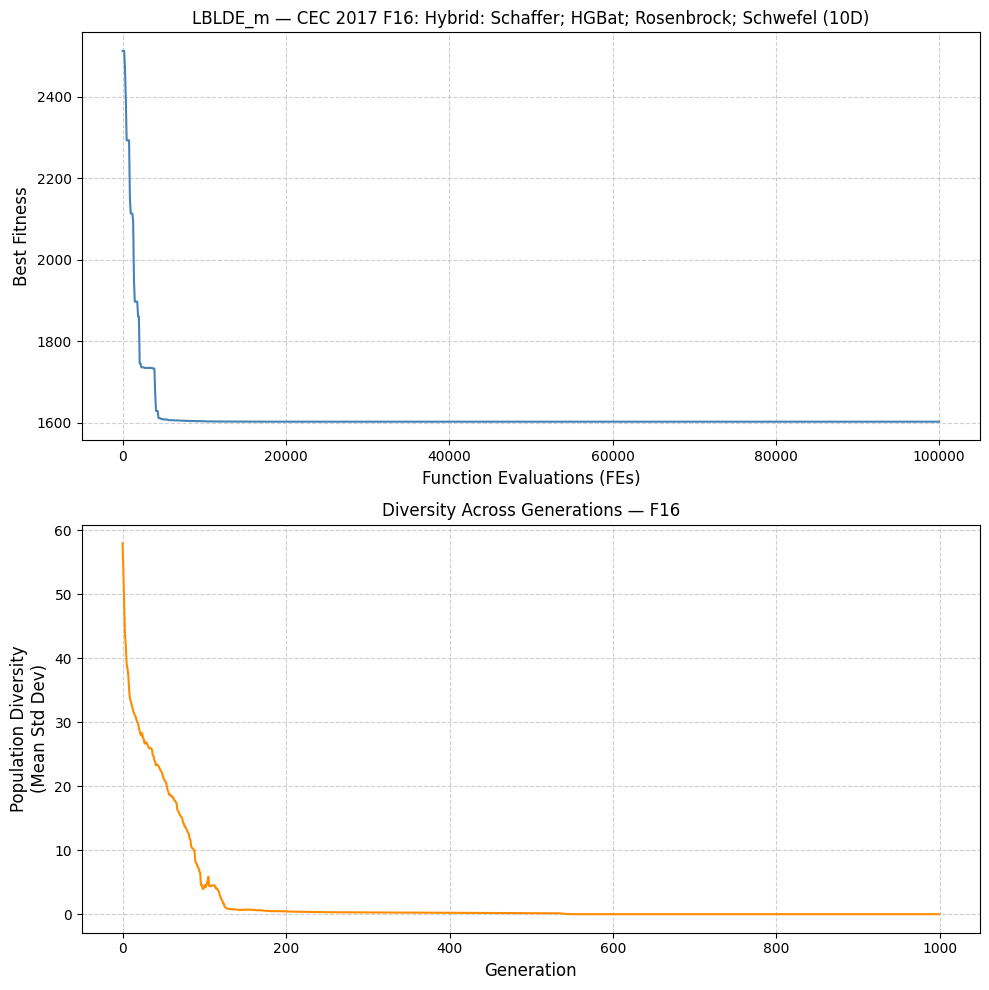

Graph saved as convergence_F16.png



In [26]:
# ============================================================
# F16 — Hybrid Function 6 (Schaffer; HGBat; Rosenbrock; Schwefel)
# ============================================================
run_and_plot('F16', make_wrapper(hybrid.f16), 1600.0, 'Hybrid: Schaffer; HGBat; Rosenbrock; Schwefel')

LBLDE_m on CEC 2017 F17 — Single Run
Function       : Hybrid: Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1700.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.471803e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 1.864212e+03  FES =   1100  Diversity = 3.3686e+01
Generation   20: Best = 1.783559e+03  FES =   2100  Diversity = 2.7388e+01
Generation   30: Best = 1.757840e+03  FES =   3100  Diversity = 2.3542e+01
Generation   40: Best = 1.731211e+03  FES =   4100  Diversity = 2.0183e+01
Generation   50: Best = 1.728428e+03  FES =   5100  Diversity = 1.7379e+01
Generation   60: Best = 1.725244e+03  FES =   6100  Diversity = 1.4963e+01
Generation   70: Best = 1.719629e+03  FES =   7100  Diversity = 1.3699e+01
Generation   80: Best = 1.706756e+03  FES =   8100  Diversity = 1.1948e+01
Generation   90: Best = 1.703644e+03  FES =   9100  Diversity = 8.7387e+00
Generation  

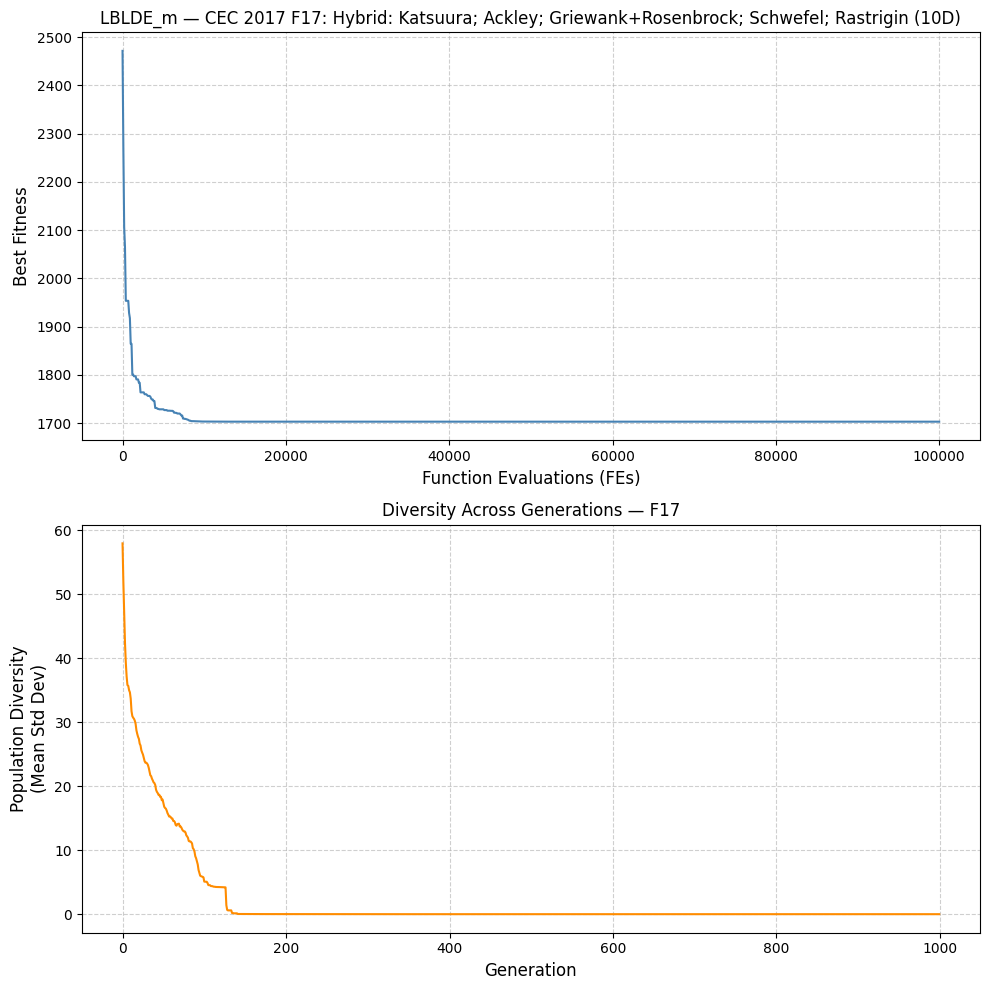

Graph saved as convergence_F17.png



In [27]:
# ============================================================
# F17 — Hybrid Function 7 (Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin)
# ============================================================
run_and_plot('F17', make_wrapper(hybrid.f17), 1700.0, 'Hybrid: Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin')

LBLDE_m on CEC 2017 F18 — Single Run
Function       : Hybrid: Elliptic; Ackley; Rastrigin; HGBat; Discus (10D)
Bounds         : [-100, 100]
Global optimum : 1800.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 6.135676e+08  |  Diversity = 5.7928e+01
Generation   10: Best = 5.240816e+05  FES =   1100  Diversity = 3.1245e+01
Generation   20: Best = 2.576724e+04  FES =   2100  Diversity = 2.4885e+01
Generation   30: Best = 4.449429e+03  FES =   3100  Diversity = 1.9727e+01
Generation   40: Best = 2.662322e+03  FES =   4100  Diversity = 1.9028e+01
Generation   50: Best = 2.051073e+03  FES =   5100  Diversity = 1.8533e+01
Generation   60: Best = 1.915077e+03  FES =   6100  Diversity = 1.6462e+01
Generation   70: Best = 1.862401e+03  FES =   7100  Diversity = 1.6234e+01
Generation   80: Best = 1.840315e+03  FES =   8100  Diversity = 1.3335e+01
Generation   90: Best = 1.829597e+03  FES =   9100  Diversity = 1.2831e+01
Generation  100: Best = 1.81

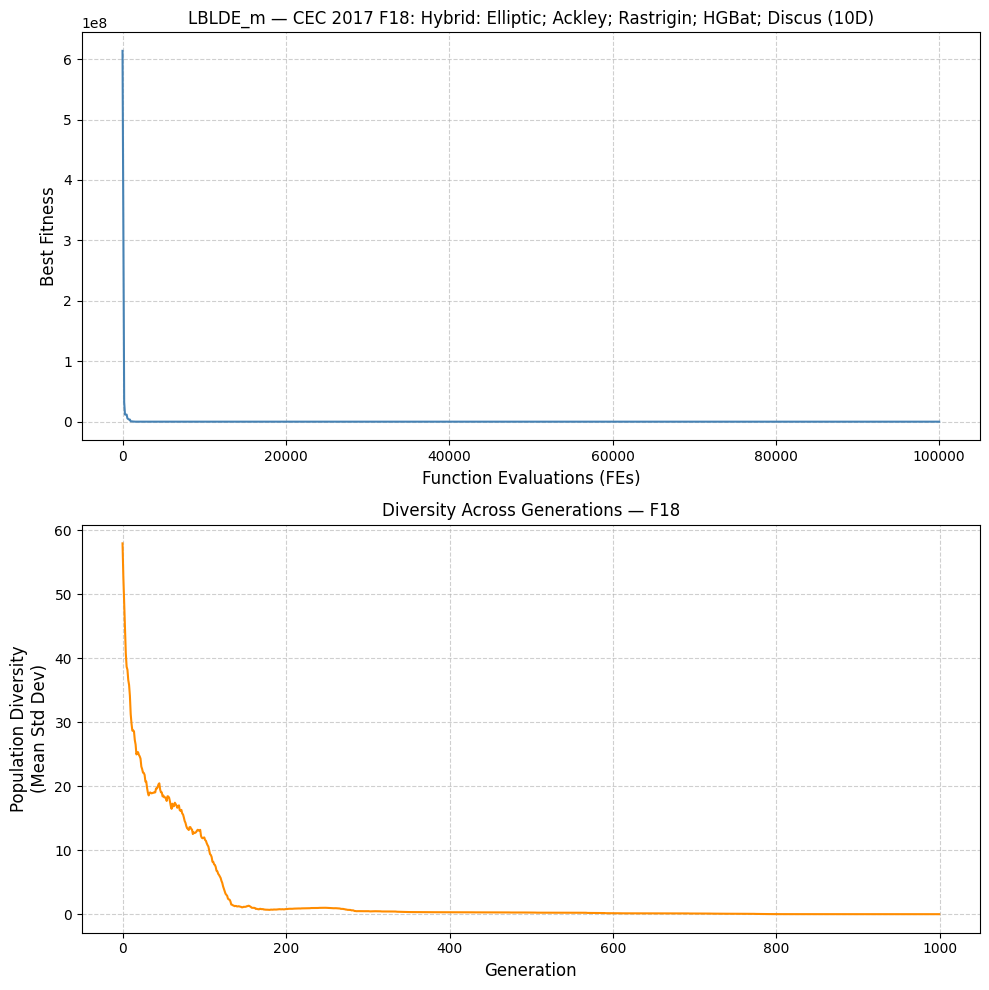

Graph saved as convergence_F18.png



In [28]:
# ============================================================
# F18 — Hybrid Function 8 (Elliptic; Ackley; Rastrigin; HGBat; Discus)
# ============================================================
run_and_plot('F18', make_wrapper(hybrid.f18), 1800.0, 'Hybrid: Elliptic; Ackley; Rastrigin; HGBat; Discus')

LBLDE_m on CEC 2017 F19 — Single Run
Function       : Hybrid: Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 1900.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.530389e+08  |  Diversity = 5.7928e+01
Generation   10: Best = 1.034464e+04  FES =   1100  Diversity = 3.1511e+01
Generation   20: Best = 2.495840e+03  FES =   2100  Diversity = 2.0336e+01
Generation   30: Best = 1.965970e+03  FES =   3100  Diversity = 1.3400e+01
Generation   40: Best = 1.937925e+03  FES =   4100  Diversity = 1.1468e+01
Generation   50: Best = 1.925879e+03  FES =   5100  Diversity = 1.2359e+01
Generation   60: Best = 1.914031e+03  FES =   6100  Diversity = 1.3038e+01
Generation   70: Best = 1.911233e+03  FES =   7100  Diversity = 1.2436e+01
Generation   80: Best = 1.907288e+03  FES =   8100  Diversity = 8.6172e+00
Generation   90: Best = 1.905855e+03  FES =   9100  Diversity = 5.3112e+00
Gener

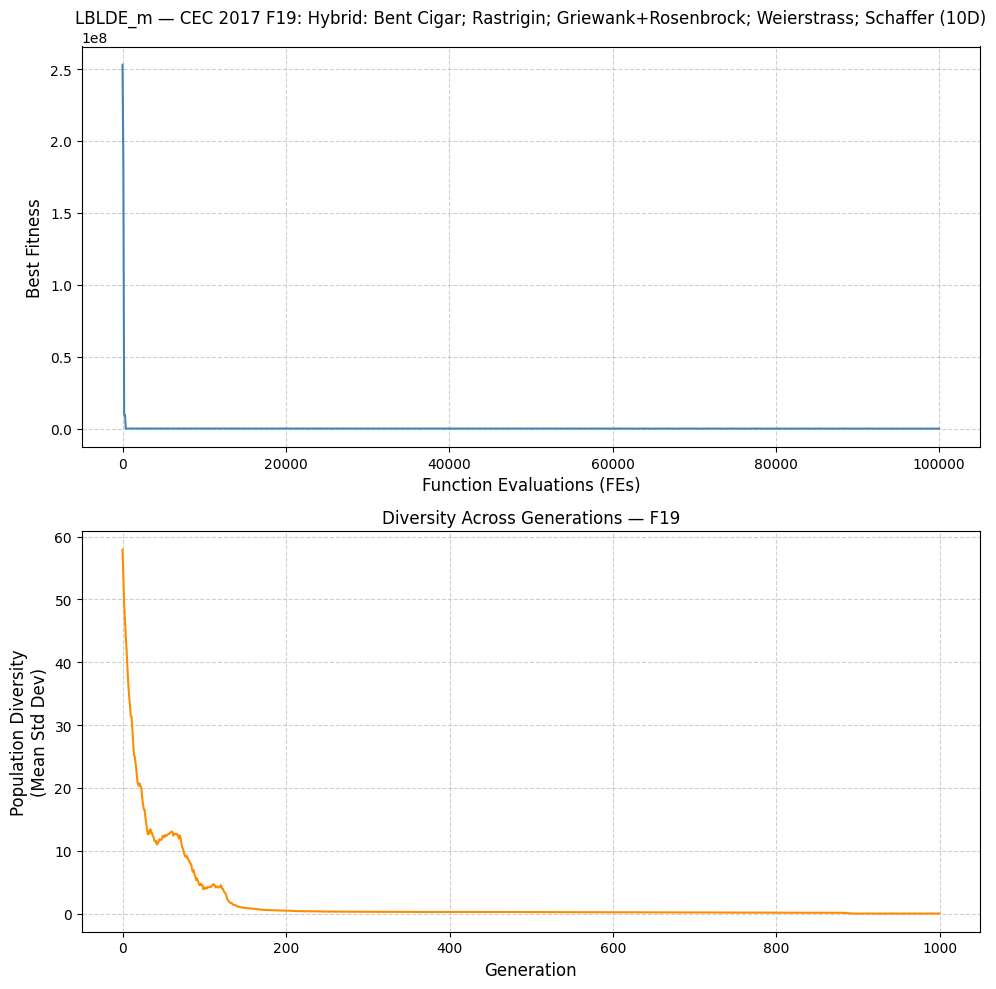

Graph saved as convergence_F19.png



In [29]:
# ============================================================
# F19 — Hybrid Function 9 (Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer)
# ============================================================
run_and_plot('F19', make_wrapper(hybrid.f19), 1900.0, 'Hybrid: Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer')

LBLDE_m on CEC 2017 F20 — Single Run
Function       : Hybrid: HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2000.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.391561e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.216701e+03  FES =   1100  Diversity = 4.1789e+01
Generation   20: Best = 2.076062e+03  FES =   2100  Diversity = 2.9336e+01
Generation   30: Best = 2.074336e+03  FES =   3100  Diversity = 1.9178e+01
Generation   40: Best = 2.052052e+03  FES =   4100  Diversity = 1.2211e+01
Generation   50: Best = 2.044088e+03  FES =   5100  Diversity = 9.2983e+00
Generation   60: Best = 2.040549e+03  FES =   6100  Diversity = 5.8560e+00
Generation   70: Best = 2.034269e+03  FES =   7100  Diversity = 4.8810e+00
Generation   80: Best = 2.030512e+03  FES =   8100  Diversity = 5.9967e+00
Generation   90: Best = 2.027621e+03  FES =   9100  Diversity = 6.3430e+00
Generation  1

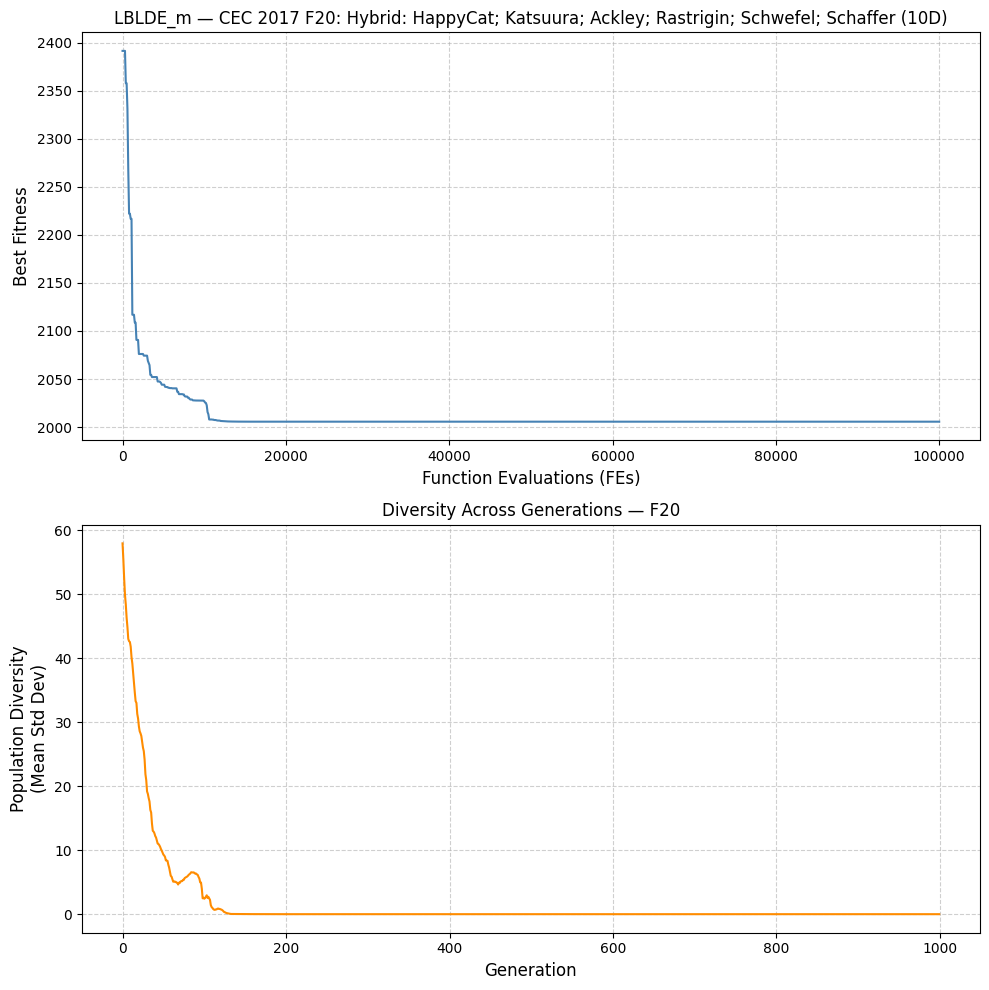

Graph saved as convergence_F20.png



In [30]:
# ============================================================
# F20 — Hybrid Function 10 (HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer)
# ============================================================
run_and_plot('F20', make_wrapper(hybrid.f20), 2000.0, 'Hybrid: HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer')

## **6.4 Composite Functions (F21-F30)**

LBLDE_m on CEC 2017 F21 — Single Run
Function       : Composition: Rosenbrock; Elliptic; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2100.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.446690e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.346661e+03  FES =   1100  Diversity = 2.9860e+01
Generation   20: Best = 2.346661e+03  FES =   2100  Diversity = 2.1916e+01
Generation   30: Best = 2.330556e+03  FES =   3100  Diversity = 2.0424e+01
Generation   40: Best = 2.293271e+03  FES =   4100  Diversity = 1.9067e+01
Generation   50: Best = 2.268566e+03  FES =   5100  Diversity = 1.8246e+01
Generation   60: Best = 2.268566e+03  FES =   6100  Diversity = 2.1490e+01
Generation   70: Best = 2.238438e+03  FES =   7100  Diversity = 2.2489e+01
Generation   80: Best = 2.237637e+03  FES =   8100  Diversity = 2.5641e+01
Generation   90: Best = 2.229023e+03  FES =   9100  Diversity = 3.0437e+01
Generation  100: Best = 2.220101e+

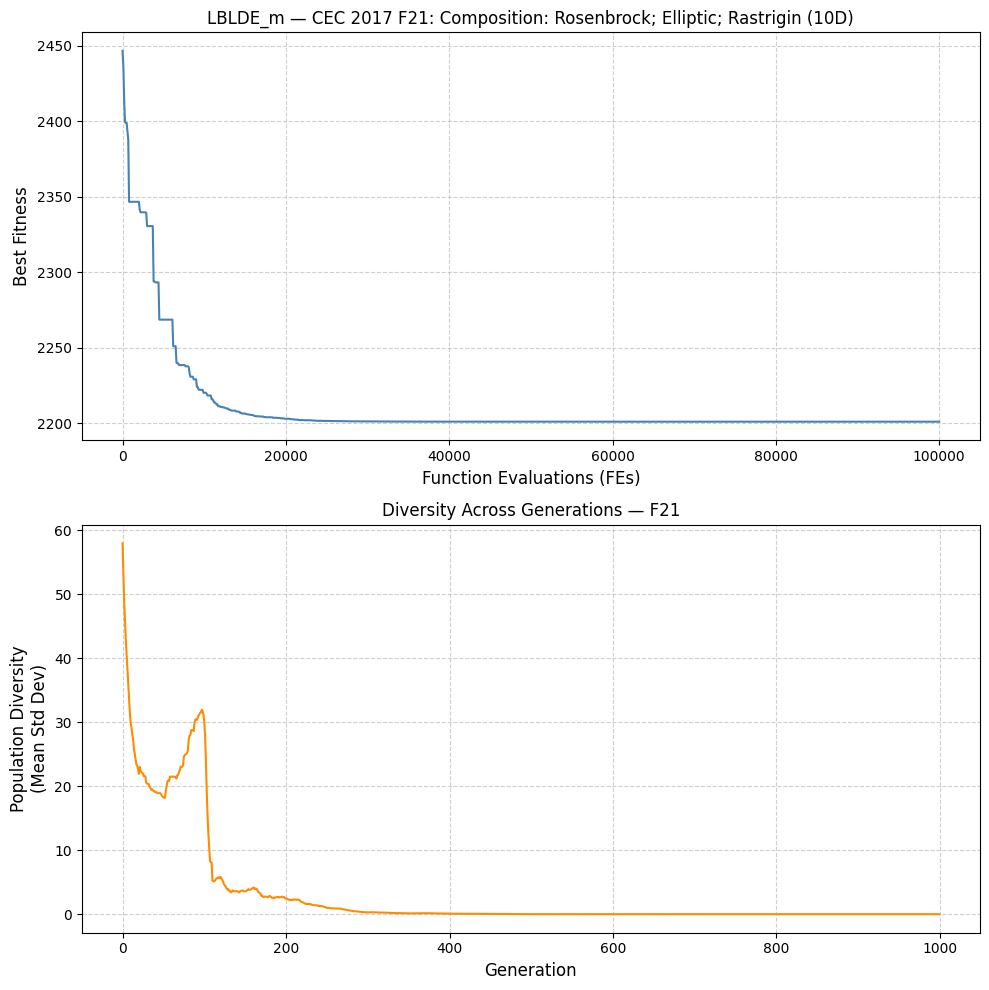

Graph saved as convergence_F21.png



In [31]:
# ============================================================
# F21 — Composition Function 1 (Rosenbrock; Elliptic; Rastrigin)
# ============================================================
run_and_plot('F21', make_wrapper(composition.f21), 2100.0, 'Composition: Rosenbrock; Elliptic; Rastrigin')

LBLDE_m on CEC 2017 F22 — Single Run
Function       : Composition: Rastrigin; Griewank; Schwefel (10D)
Bounds         : [-100, 100]
Global optimum : 2200.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.528003e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.348865e+03  FES =   1100  Diversity = 1.3355e+01
Generation   20: Best = 2.316434e+03  FES =   2100  Diversity = 2.4421e+00
Generation   30: Best = 2.310922e+03  FES =   3100  Diversity = 8.2335e-01
Generation   40: Best = 2.306065e+03  FES =   4100  Diversity = 5.5755e-01
Generation   50: Best = 2.303815e+03  FES =   5100  Diversity = 5.0094e-01
Generation   60: Best = 2.302286e+03  FES =   6100  Diversity = 4.4500e-01
Generation   70: Best = 2.302096e+03  FES =   7100  Diversity = 3.9507e-01
Generation   80: Best = 2.301992e+03  FES =   8100  Diversity = 3.3098e-01
Generation   90: Best = 2.301909e+03  FES =   9100  Diversity = 2.9524e-01
Generation  100: Best = 2.301877e+03

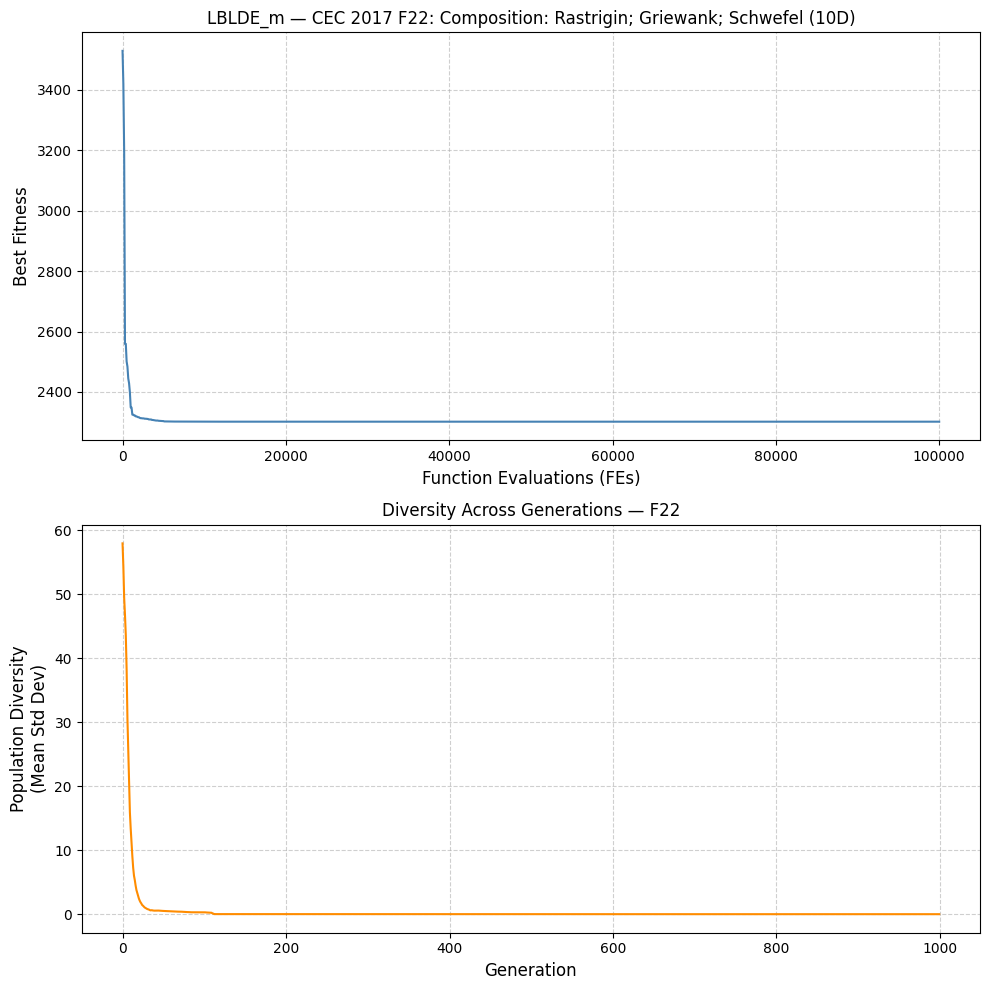

Graph saved as convergence_F22.png



In [32]:
# ============================================================
# F22 — Composition Function 2 (Rastrigin; Griewank; Schwefel)
# ============================================================
run_and_plot('F22', make_wrapper(composition.f22), 2200.0, 'Composition: Rastrigin; Griewank; Schwefel')

LBLDE_m on CEC 2017 F23 — Single Run
Function       : Composition: Rosenbrock; Ackley; Schwefel; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2300.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.773921e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.681356e+03  FES =   1100  Diversity = 2.3287e+01
Generation   20: Best = 2.649530e+03  FES =   2100  Diversity = 1.8334e+01
Generation   30: Best = 2.646652e+03  FES =   3100  Diversity = 1.5791e+01
Generation   40: Best = 2.645968e+03  FES =   4100  Diversity = 1.4882e+01
Generation   50: Best = 2.623666e+03  FES =   5100  Diversity = 1.4108e+01
Generation   60: Best = 2.614995e+03  FES =   6100  Diversity = 1.3904e+01
Generation   70: Best = 2.614692e+03  FES =   7100  Diversity = 1.3218e+01
Generation   80: Best = 2.614341e+03  FES =   8100  Diversity = 1.2617e+01
Generation   90: Best = 2.613562e+03  FES =   9100  Diversity = 1.2203e+01
Generation  100: Best = 2.

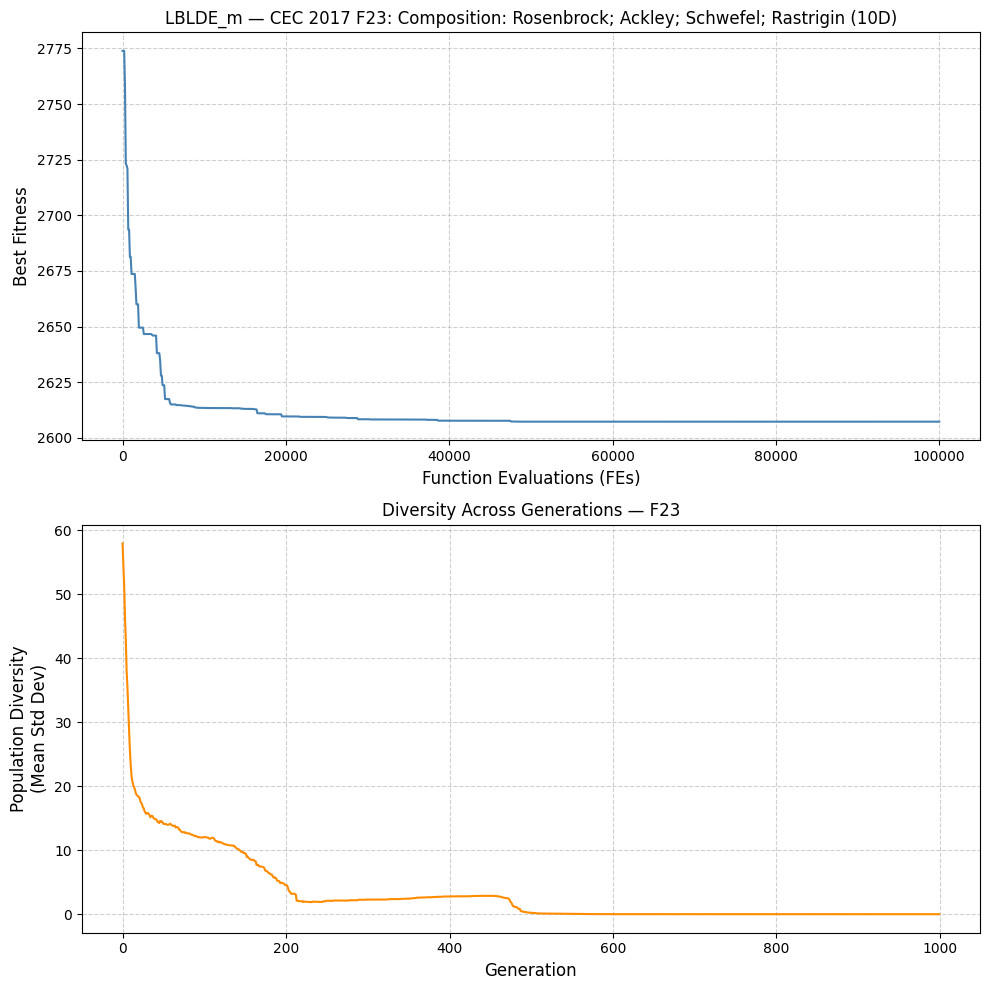

Graph saved as convergence_F23.png



In [33]:
# ============================================================
# F23 — Composition Function 3 (Rosenbrock; Ackley; Schwefel; Rastrigin)
# ============================================================
run_and_plot('F23', make_wrapper(composition.f23), 2300.0, 'Composition: Rosenbrock; Ackley; Schwefel; Rastrigin')

LBLDE_m on CEC 2017 F24 — Single Run
Function       : Composition: Ackley; Elliptic; Griewank; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2400.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.997998e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.795118e+03  FES =   1100  Diversity = 2.1538e+01
Generation   20: Best = 2.785385e+03  FES =   2100  Diversity = 1.2914e+01
Generation   30: Best = 2.766216e+03  FES =   3100  Diversity = 1.0997e+01
Generation   40: Best = 2.758597e+03  FES =   4100  Diversity = 9.8297e+00
Generation   50: Best = 2.757784e+03  FES =   5100  Diversity = 9.4706e+00
Generation   60: Best = 2.745489e+03  FES =   6100  Diversity = 8.8803e+00
Generation   70: Best = 2.743765e+03  FES =   7100  Diversity = 8.7462e+00
Generation   80: Best = 2.743372e+03  FES =   8100  Diversity = 8.5475e+00
Generation   90: Best = 2.740251e+03  FES =   9100  Diversity = 8.2559e+00
Generation  100: Best = 2.73

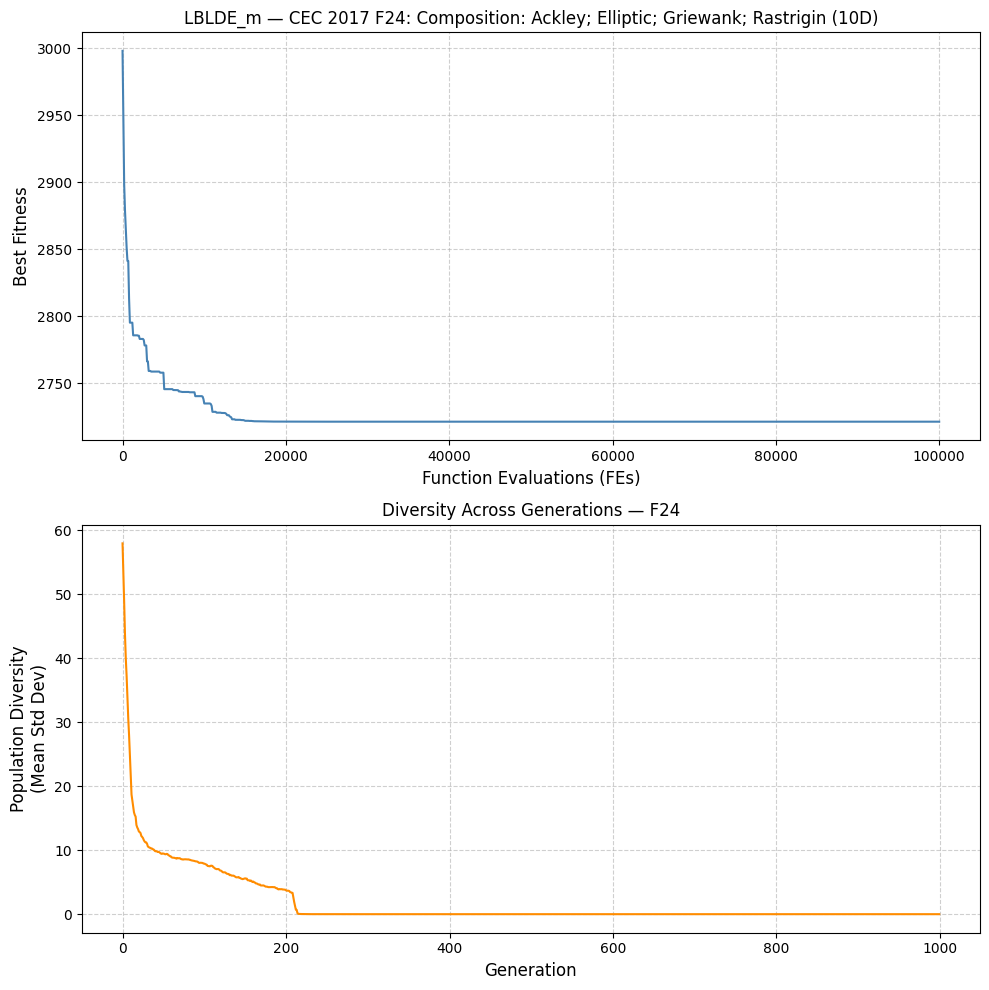

Graph saved as convergence_F24.png



In [34]:
# ============================================================
# F24 — Composition Function 4 (Ackley; Elliptic; Griewank; Rastrigin)
# ============================================================
run_and_plot('F24', make_wrapper(composition.f24), 2400.0, 'Composition: Ackley; Elliptic; Griewank; Rastrigin')

LBLDE_m on CEC 2017 F25 — Single Run
Function       : Composition: Rastrigin; HappyCat; Ackley; Discus; Rosenbrock (10D)
Bounds         : [-100, 100]
Global optimum : 2500.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 4.081798e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 2.957208e+03  FES =   1100  Diversity = 1.3269e+01
Generation   20: Best = 2.949072e+03  FES =   2100  Diversity = 2.3843e+00
Generation   30: Best = 2.947054e+03  FES =   3100  Diversity = 9.8954e-01
Generation   40: Best = 2.946605e+03  FES =   4100  Diversity = 7.5196e-01
Generation   50: Best = 2.946295e+03  FES =   5100  Diversity = 6.7590e-01
Generation   60: Best = 2.946145e+03  FES =   6100  Diversity = 5.6314e-01
Generation   70: Best = 2.946127e+03  FES =   7100  Diversity = 5.3138e-01
Generation   80: Best = 2.946124e+03  FES =   8100  Diversity = 5.3118e-01
Generation   90: Best = 2.946123e+03  FES =   9100  Diversity = 5.0156e-01
Generation  100: B

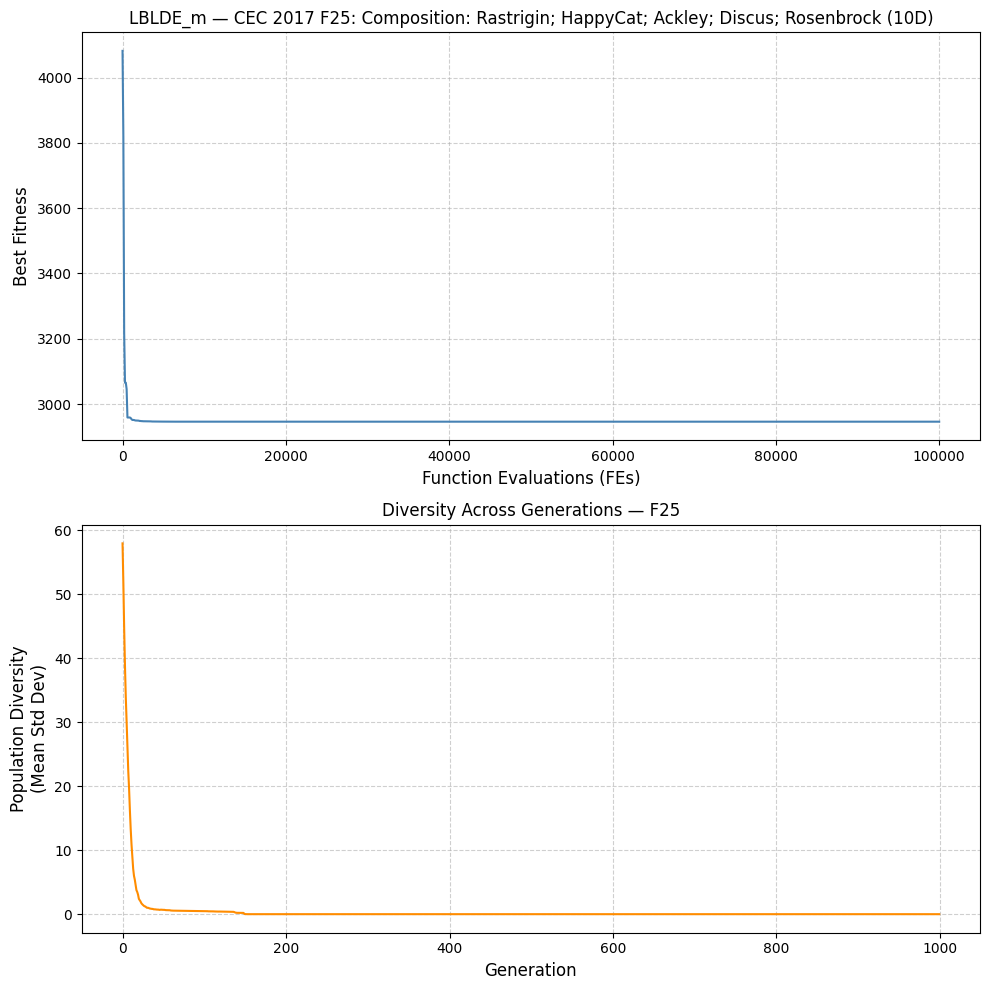

Graph saved as convergence_F25.png



In [35]:
# ============================================================
# F25 — Composition Function 5 (Rastrigin; HappyCat; Ackley; Discus; Rosenbrock)
# ============================================================
run_and_plot('F25', make_wrapper(composition.f25), 2500.0, 'Composition: Rastrigin; HappyCat; Ackley; Discus; Rosenbrock')

LBLDE_m on CEC 2017 F26 — Single Run
Function       : Composition: Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2600.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 4.061684e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 3.423833e+03  FES =   1100  Diversity = 2.0399e+01
Generation   20: Best = 3.114023e+03  FES =   2100  Diversity = 6.1499e+00
Generation   30: Best = 3.030493e+03  FES =   3100  Diversity = 2.7991e+00
Generation   40: Best = 3.007999e+03  FES =   4100  Diversity = 1.2726e+00
Generation   50: Best = 2.994763e+03  FES =   5100  Diversity = 8.9572e-01
Generation   60: Best = 2.982917e+03  FES =   6100  Diversity = 4.0459e-01
Generation   70: Best = 2.981077e+03  FES =   7100  Diversity = 1.7764e-01
Generation   80: Best = 2.979441e+03  FES =   8100  Diversity = 1.2808e-01
Generation   90: Best = 2.978629e+03  FES =   9100  Diversity = 9.7298e-02
Generation  10

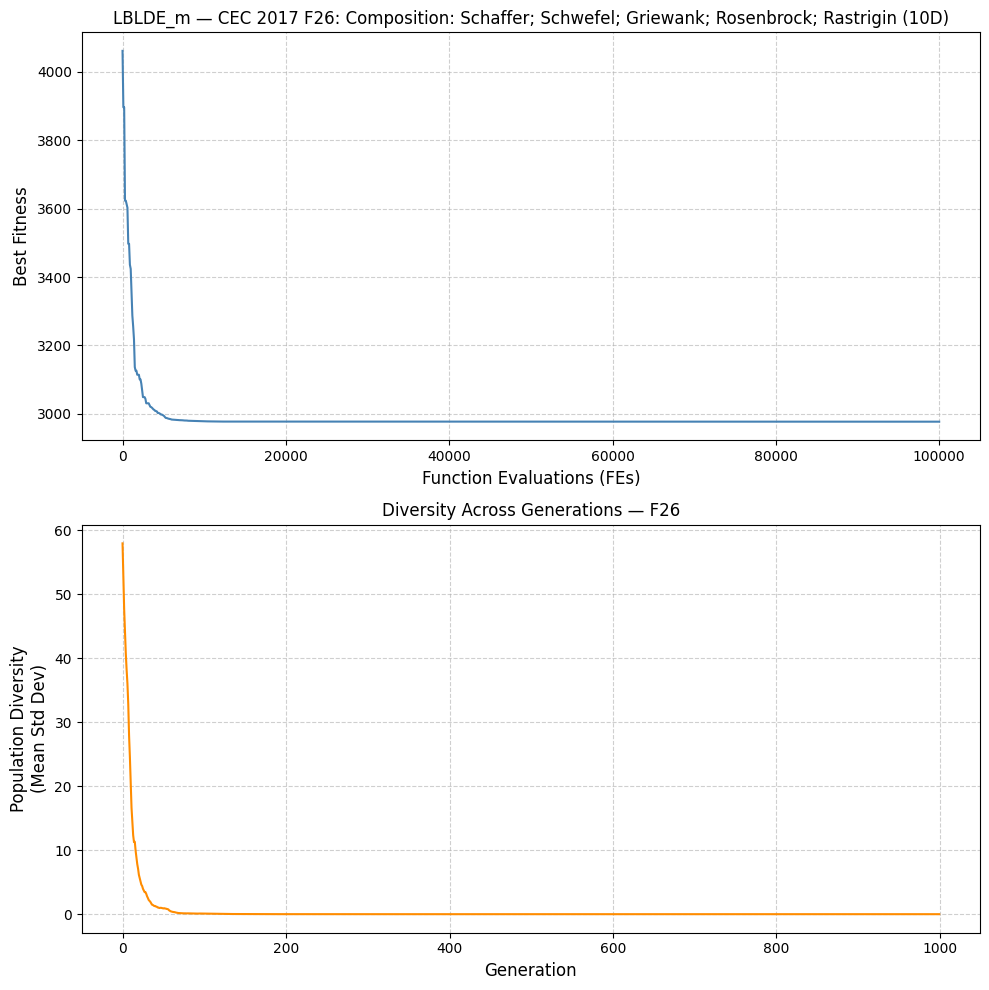

Graph saved as convergence_F26.png



In [36]:
# ============================================================
# F26 — Composition Function 6 (Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin)
# ============================================================
run_and_plot('F26', make_wrapper(composition.f26), 2600.0, 'Composition: Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin')

LBLDE_m on CEC 2017 F27 — Single Run
Function       : Composition: HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2700.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.284356e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 3.143600e+03  FES =   1100  Diversity = 3.2813e+01
Generation   20: Best = 3.106315e+03  FES =   2100  Diversity = 1.0257e+01
Generation   30: Best = 3.096229e+03  FES =   3100  Diversity = 4.6477e+00
Generation   40: Best = 3.094197e+03  FES =   4100  Diversity = 3.9345e+00
Generation   50: Best = 3.093777e+03  FES =   5100  Diversity = 3.5598e+00
Generation   60: Best = 3.093718e+03  FES =   6100  Diversity = 3.2215e+00
Generation   70: Best = 3.093689e+03  FES =   7100  Diversity = 2.6162e+00
Generation   80: Best = 3.093680e+03  FES =   8100  Diversity = 2.4932e+00
Generation   90: Best = 3.093677e+03  FES =   9100  Diversity = 2.2406e+00
Generat

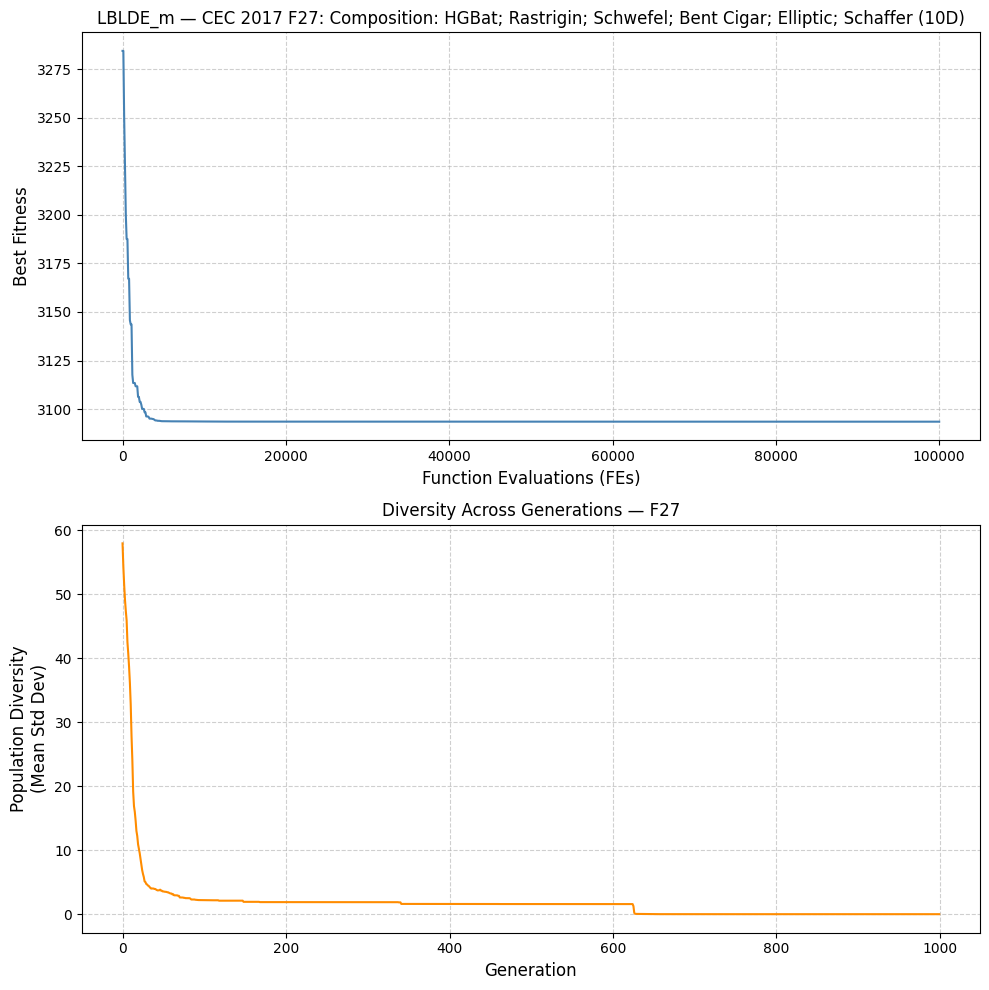

Graph saved as convergence_F27.png



In [37]:
# ============================================================
# F27 — Composition Function 7 (HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer)
# ============================================================
run_and_plot('F27', make_wrapper(composition.f27), 2700.0, 'Composition: HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer')

LBLDE_m on CEC 2017 F28 — Single Run
Function       : Composition: Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2800.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 4.188047e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 3.270183e+03  FES =   1100  Diversity = 3.3193e+01
Generation   20: Best = 3.181375e+03  FES =   2100  Diversity = 1.2744e+01
Generation   30: Best = 3.175718e+03  FES =   3100  Diversity = 1.9757e+00
Generation   40: Best = 3.173296e+03  FES =   4100  Diversity = 1.5241e+00
Generation   50: Best = 3.170347e+03  FES =   5100  Diversity = 1.4447e+00
Generation   60: Best = 3.164278e+03  FES =   6100  Diversity = 1.4411e+00
Generation   70: Best = 3.155417e+03  FES =   7100  Diversity = 1.2133e+00
Generation   80: Best = 3.148275e+03  FES =   8100  Diversity = 9.4956e-01
Generation   90: Best = 3.144672e+03  FES =   9100  Diversity = 6.4447e-01
Generatio

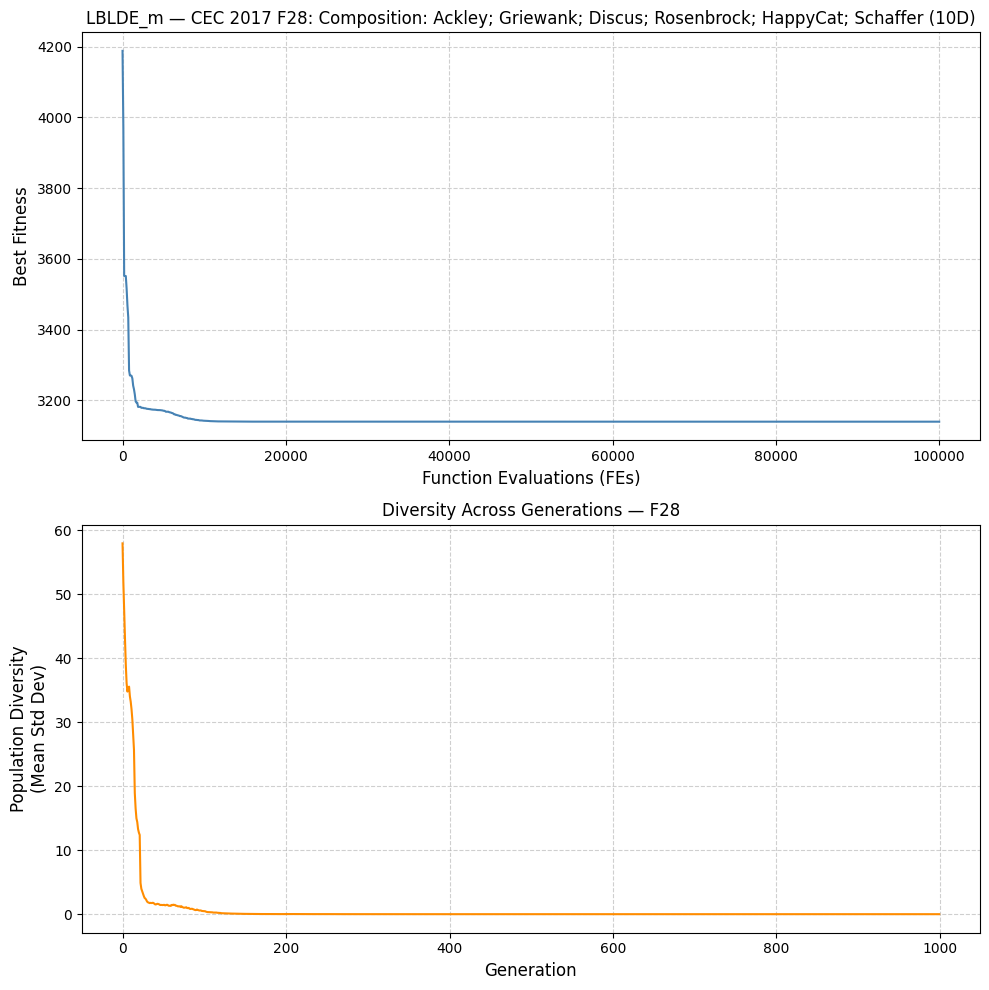

Graph saved as convergence_F28.png



In [38]:
# ============================================================
# F28 — Composition Function 8 (Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer)
# ============================================================
run_and_plot('F28', make_wrapper(composition.f28), 2800.0, 'Composition: Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer')

LBLDE_m on CEC 2017 F29 — Single Run
Function       : Composition: F15; F16; F17 (10D)
Bounds         : [-100, 100]
Global optimum : 2900.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.805371e+03  |  Diversity = 5.7928e+01
Generation   10: Best = 3.450402e+03  FES =   1100  Diversity = 4.3503e+01
Generation   20: Best = 3.254916e+03  FES =   2100  Diversity = 3.7397e+01
Generation   30: Best = 3.224870e+03  FES =   3100  Diversity = 3.2564e+01
Generation   40: Best = 3.222870e+03  FES =   4100  Diversity = 2.9490e+01
Generation   50: Best = 3.222870e+03  FES =   5100  Diversity = 2.6756e+01
Generation   60: Best = 3.210205e+03  FES =   6100  Diversity = 2.4008e+01
Generation   70: Best = 3.203366e+03  FES =   7100  Diversity = 2.3078e+01
Generation   80: Best = 3.203366e+03  FES =   8100  Diversity = 2.0863e+01
Generation   90: Best = 3.203366e+03  FES =   9100  Diversity = 2.0947e+01
Generation  100: Best = 3.203366e+03  FES =  10100  

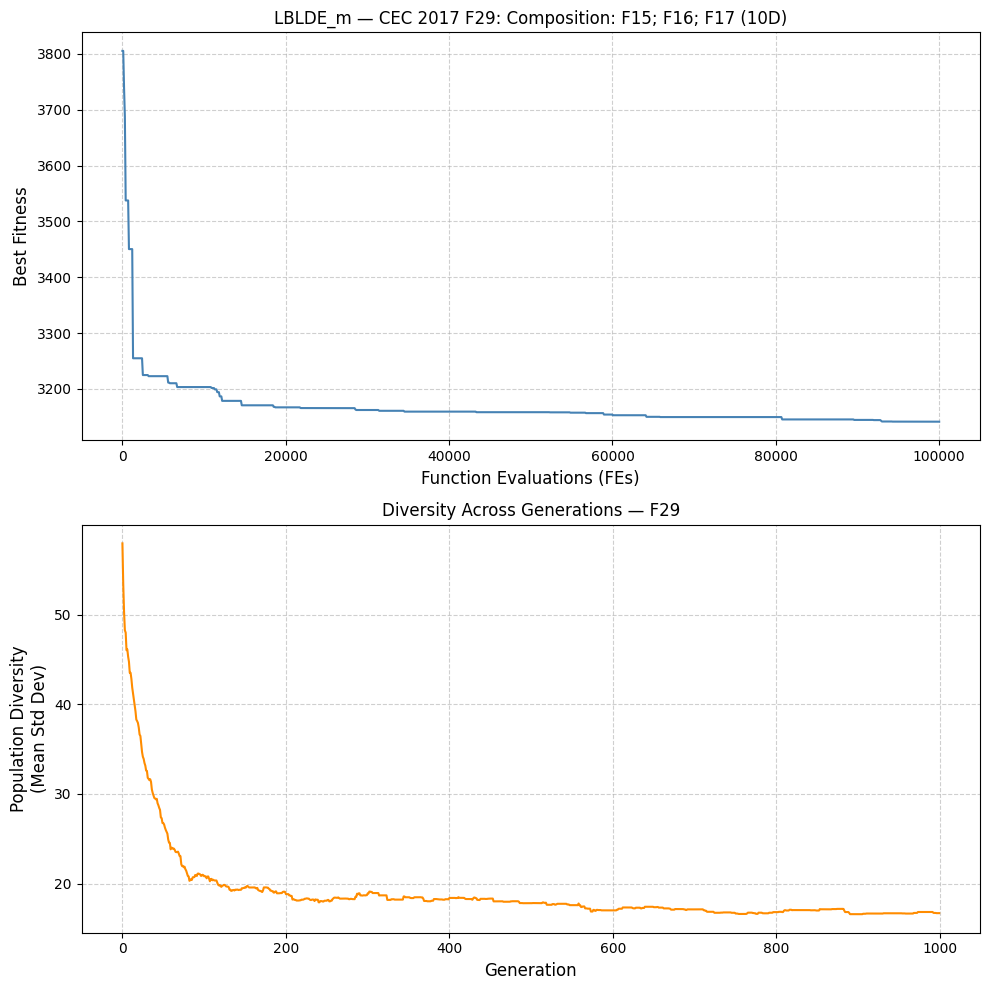

Graph saved as convergence_F29.png



In [39]:
# ============================================================
# F29 — Composition Function 9 (F15; F16; F17)
# ============================================================
run_and_plot('F29', make_wrapper(composition.f29), 2900.0, 'Composition: F15; F16; F17')

LBLDE_m on CEC 2017 F30 — Single Run
Function       : Composition: F15; F18; F19 (10D)
Bounds         : [-100, 100]
Global optimum : 3000.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.165390e+08  |  Diversity = 5.7928e+01
Generation   10: Best = 1.124585e+07  FES =   1100  Diversity = 4.3531e+01
Generation   20: Best = 8.137738e+06  FES =   2100  Diversity = 3.5997e+01
Generation   30: Best = 3.908748e+06  FES =   3100  Diversity = 3.3433e+01
Generation   40: Best = 7.519525e+05  FES =   4100  Diversity = 3.0909e+01
Generation   50: Best = 2.968729e+05  FES =   5100  Diversity = 2.9195e+01
Generation   60: Best = 2.731725e+05  FES =   6100  Diversity = 2.3833e+01
Generation   70: Best = 2.214610e+05  FES =   7100  Diversity = 1.9753e+01
Generation   80: Best = 6.094907e+04  FES =   8100  Diversity = 2.0132e+01
Generation   90: Best = 4.669540e+04  FES =   9100  Diversity = 1.8017e+01
Generation  100: Best = 2.895193e+04  FES =  10100  

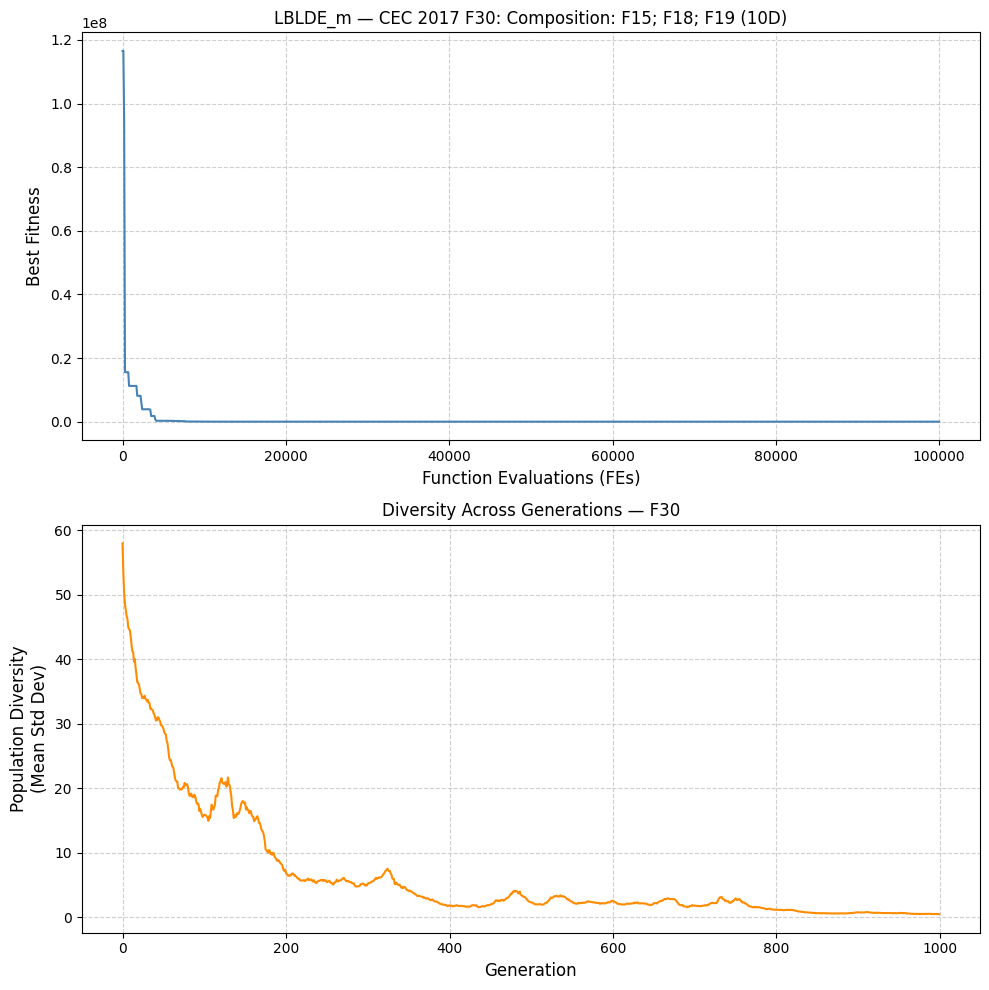

Graph saved as convergence_F30.png



In [40]:
# ============================================================
# F30 — Composition Function 10 (F15; F18; F19)
# ============================================================
run_and_plot('F30', make_wrapper(composition.f30), 3000.0, 'Composition: F15; F18; F19')

# ***Section 7. Compiled Results***

---



Print out a summary of all results in a tabular format

In [42]:
print('=' * 80)
print('SUMMARY — LBLDE_m on CEC 2017 (10D), Single Run, Seed=42')
print('=' * 80)
print(f'{"Function":<10} {"Best Fitness":>18} {"Global Optimum":>18} {"Error |best-opt|":>18}')
print('-' * 70)
for fn in [f'F{i}' for i in range(1, 31)]:
    if fn not in all_results:
        continue
    r = all_results[fn]
    if r['best_fit'] is None:
        print(f'{fn:<10} {"N/A (deprecated)":>18} {r["f_global"]:>18.2f} {"N/A":>18}')
    else:
        print(f'{fn:<10} {r["best_fit"]:>18.6e} {r["f_global"]:>18.2f} {r["error"]:>18.6e}')
print('=' * 80)

SUMMARY — LBLDE_m on CEC 2017 (10D), Single Run, Seed=42
Function         Best Fitness     Global Optimum   Error |best-opt|
----------------------------------------------------------------------
F1               1.516031e+07             100.00       1.516021e+07
F2               2.372558e+03             200.00       2.172558e+03
F3               4.002712e+02             300.00       1.002712e+02
F4               4.039156e+02             400.00       3.915600e+00
F5               5.019918e+02             500.00       1.991785e+00
F6               6.000578e+02             600.00       5.775676e-02
F7               7.124535e+02             700.00       1.245351e+01
F8               8.039825e+02             800.00       3.982451e+00
F9               9.001974e+02             900.00       1.974188e-01
F10              1.003487e+03            1000.00       3.487353e+00
F11              1.110019e+03            1100.00       1.001882e+01
F12              1.318652e+03            1200.00       1